**Installation of Necessary Libraries and Dependencies**

In [218]:
!pip install arch
!pip install ruptures
!pip install yfinance
!pip install pandas-datareader
!pip install causalimpact

In [ ]:
import zipfile
import os

# Define the file path
zip_file_path = "/content/API_SP.POP.TOTL_DS2_en_csv_v2_12.zip"
extract_path = "/content/extracted_data"

# Create a directory to extract files if it doesn't exist
os.makedirs(extract_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Files extracted to: {extract_path}")

Files extracted to: /content/extracted_data


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UNEMPLOY.csv to UNEMPLOY.csv


**Time Series Analysis**

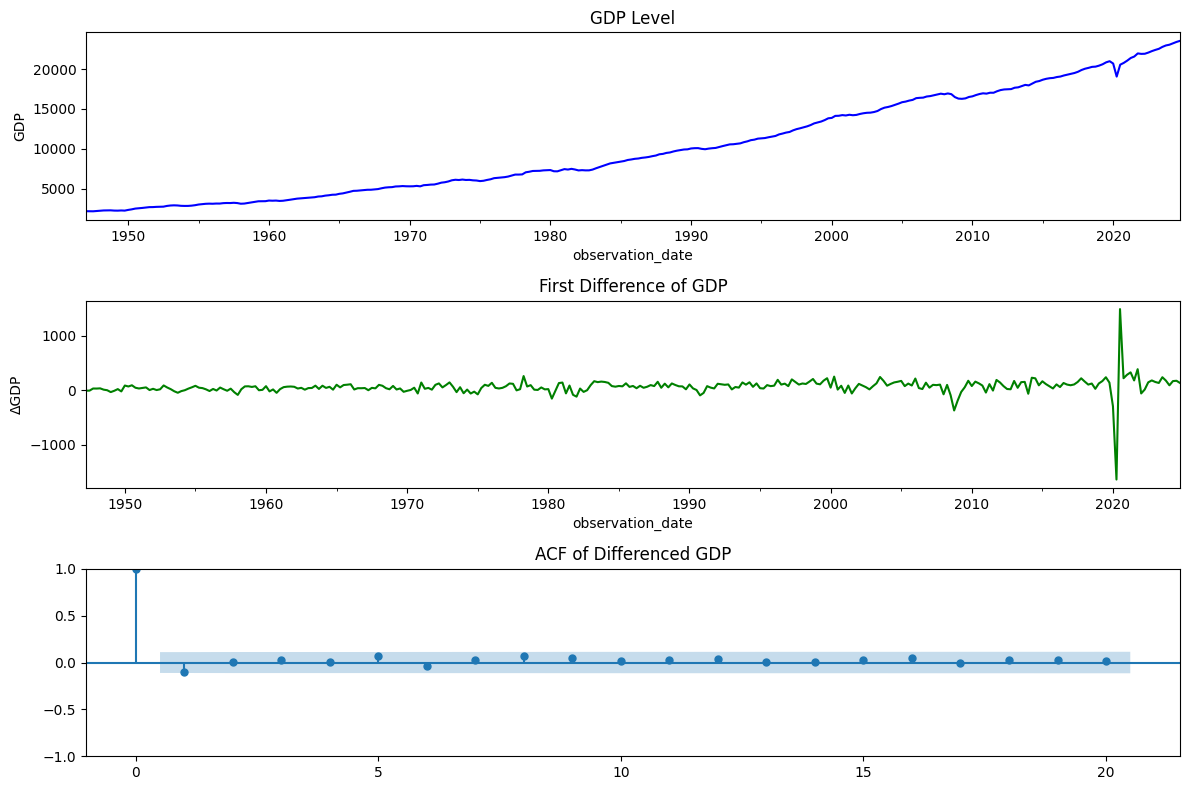

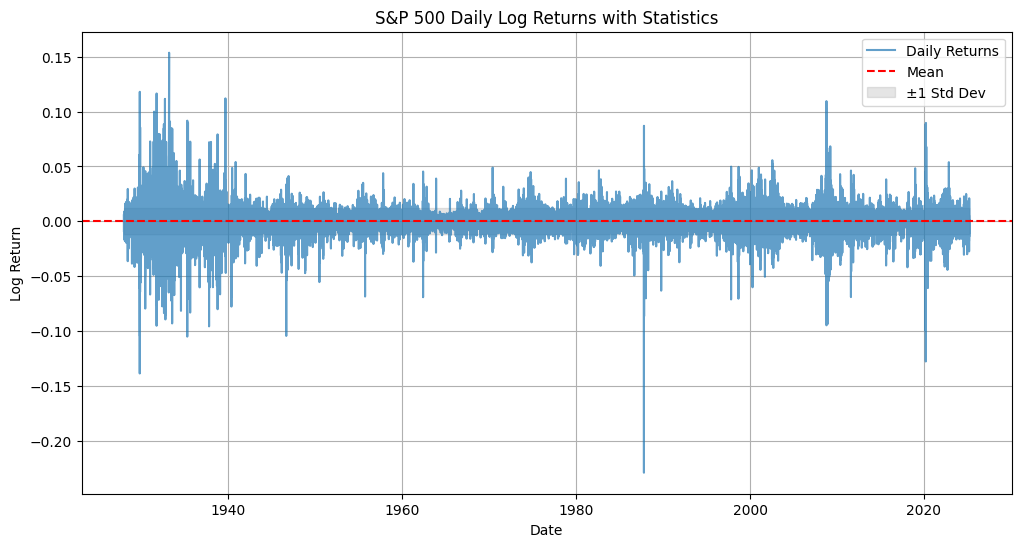

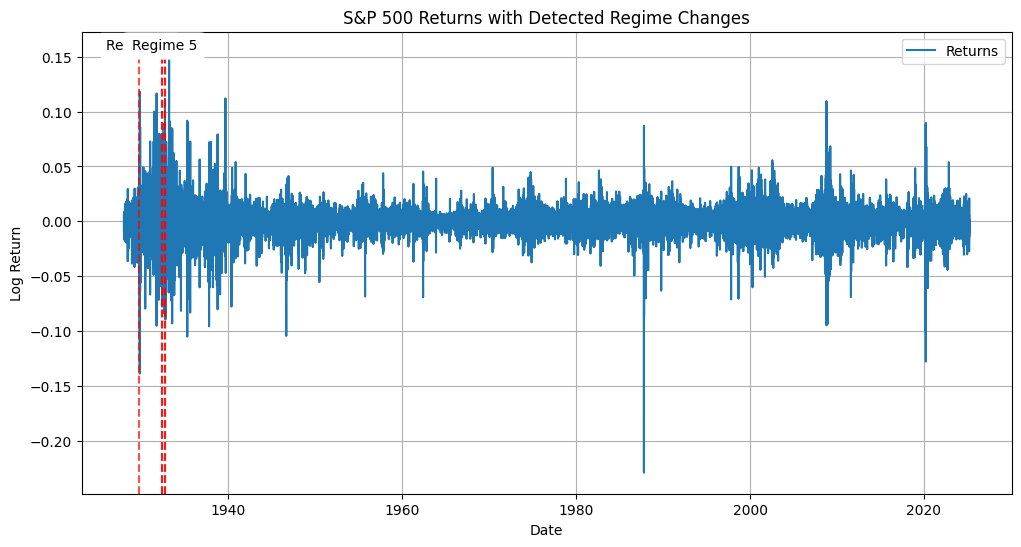

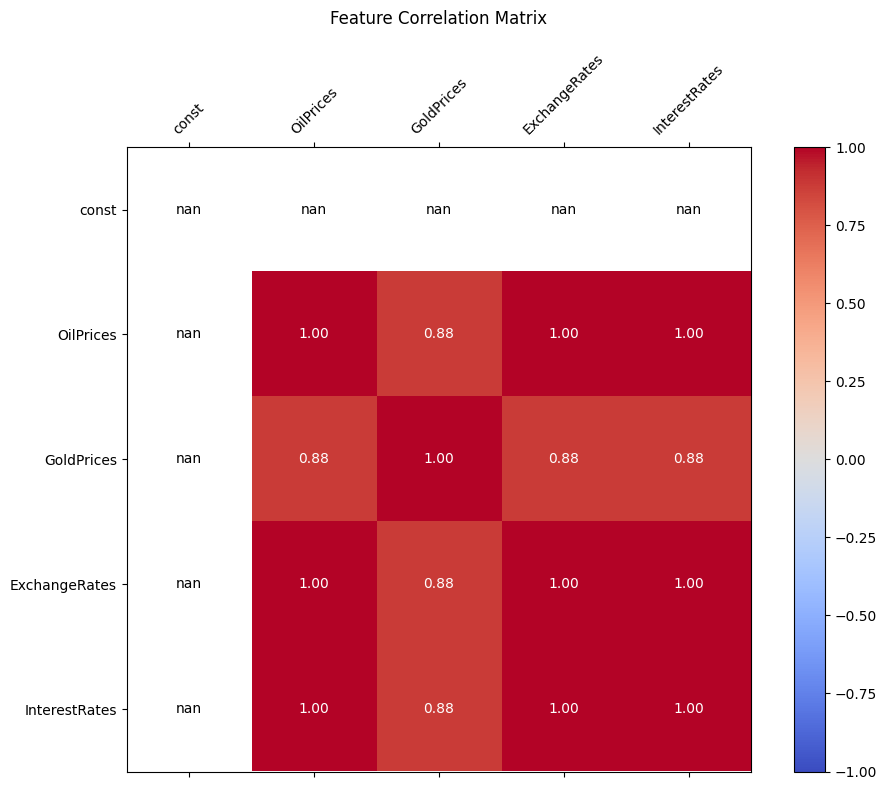

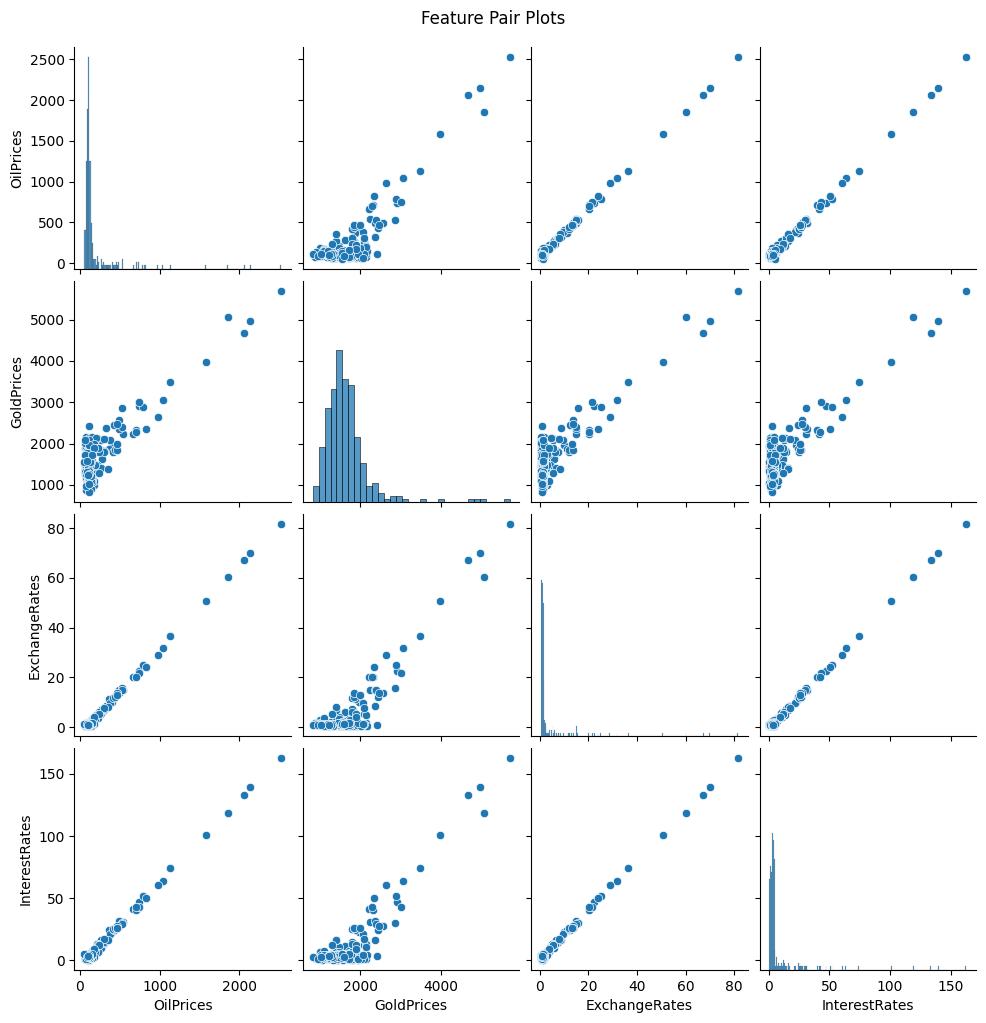

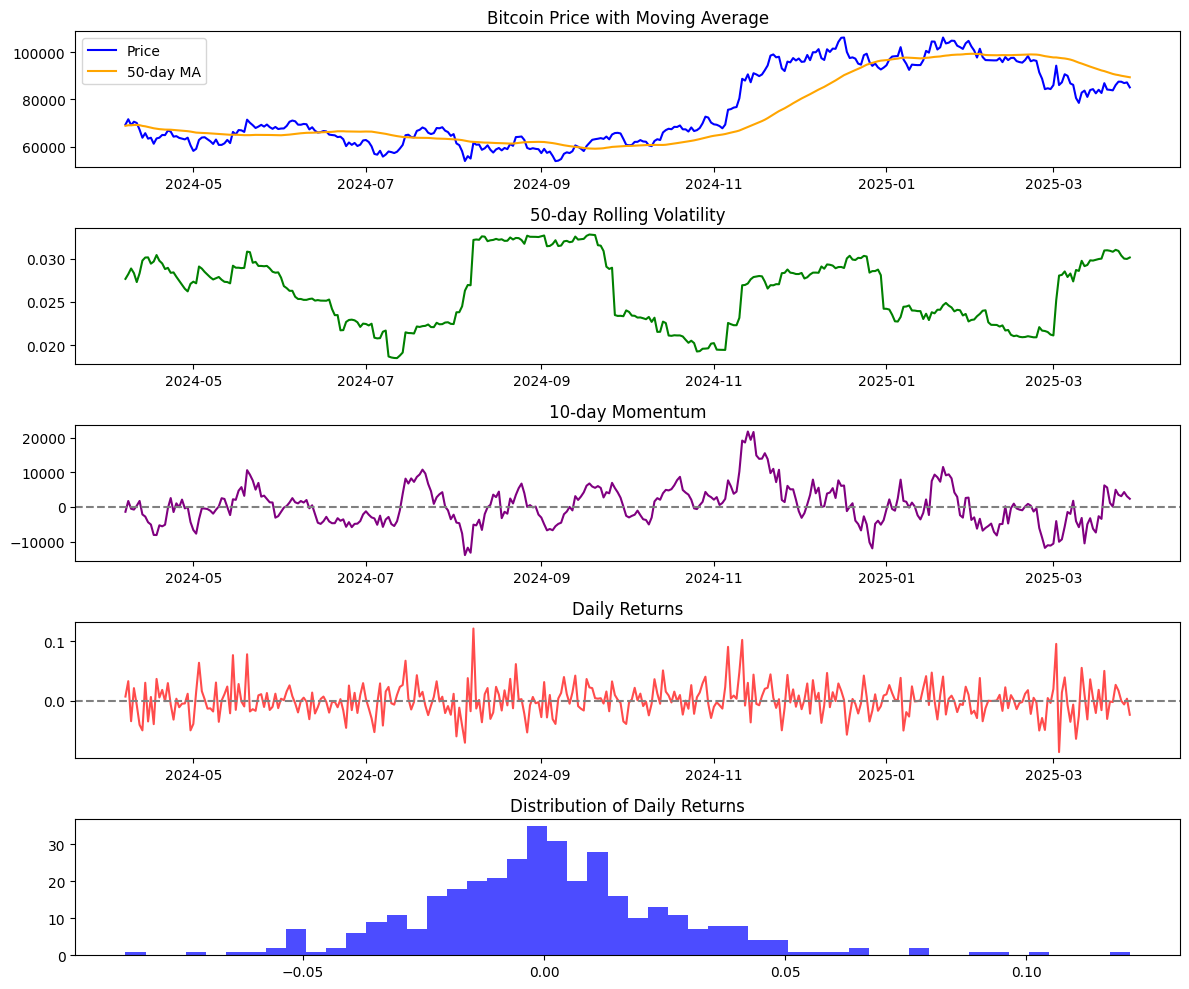

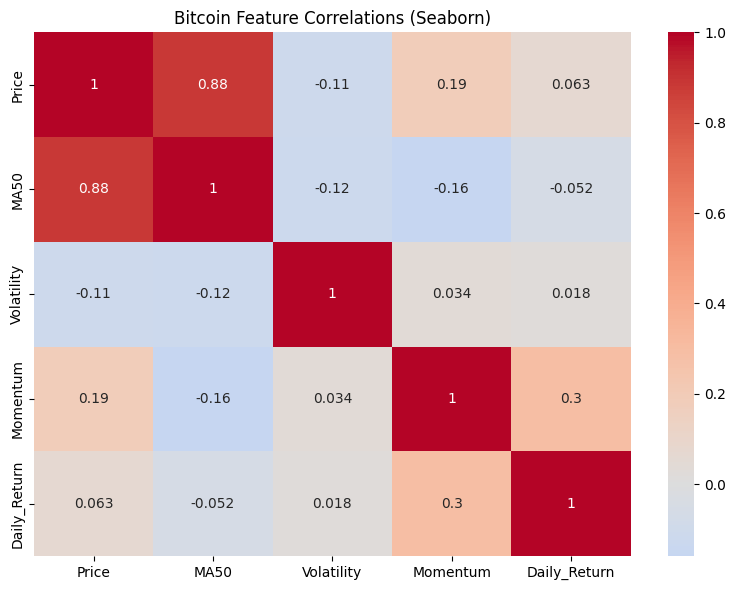

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from arch.unitroot import PhillipsPerron
from pathlib import Path
import logging
from typing import Optional, Dict, Any, List

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[logging.StreamHandler()]
)
logger = logging.getLogger(__name__)

# Check for optional dependencies
try:
    import seaborn as sns
    SEABORN_AVAILABLE = True
except ImportError:
    SEABORN_AVAILABLE = False
    logger.info("Seaborn not available, using matplotlib for visualizations")

def safe_read_csv(file_path: str, expected_cols: Optional[List[str]] = None, **kwargs) -> Optional[pd.DataFrame]:
    """Safely read CSV file with comprehensive error handling, column validation, and automatic column name matching."""
    try:
        path = Path(file_path)
        if not path.exists():
            logger.error(f"File not found: {file_path}")
            return None
        if path.stat().st_size == 0:
            logger.error(f"Empty file: {file_path}")
            return None

        # First try to read just the header to check columns
        try:
            header_df = pd.read_csv(file_path, nrows=0)
            actual_cols = header_df.columns.tolist()

            # Special handling for World Bank data format
            if "API_SP.POP.TOTL" in path.name:
                logger.info("Detected World Bank data format - applying special handling")
                df = pd.read_csv(file_path, skiprows=4)
                df = df.dropna(axis=1, how='all')  # Drop empty columns

                # Validate we have at least some data columns
                year_cols = [col for col in df.columns if col.isdigit()]
                if not year_cols:
                    logger.error("No year columns found in World Bank data")
                    return None
                return df

            # Handle column name matching if expected_cols is provided
            if expected_cols:
                # Create case-insensitive mapping
                col_map = {col.lower(): col for col in actual_cols}
                matched_cols = {}

                for expected in expected_cols:
                    lower_expected = expected.lower()
                    if lower_expected in col_map:
                        matched_cols[expected] = col_map[lower_expected]
                    else:
                        logger.warning(f"Expected column '{expected}' not found in file (case-insensitive check)")

                # If we matched all expected columns, use the mapping
                if len(matched_cols) == len(expected_cols):
                    df = pd.read_csv(file_path, **kwargs)
                    return df.rename(columns={v: k for k, v in matched_cols.items()})
                else:
                    logger.error(f"Could not match all expected columns. Found: {actual_cols}")
                    return None

            # Default case - read with provided kwargs
            return pd.read_csv(file_path, **kwargs)

        except pd.errors.EmptyDataError:
            logger.error(f"Empty data in file: {file_path}")
        except pd.errors.ParserError:
            logger.error(f"Error parsing file: {file_path}")

    except PermissionError:
        logger.error(f"Permission denied for file: {file_path}")
    except Exception as e:
        logger.error(f"Unexpected error reading {file_path}: {str(e)}")
    return None

def validate_dataframe(df: pd.DataFrame, required_cols: List[str], operation_name: str) -> bool:
    """Validate DataFrame structure and content with comprehensive checks."""
    if not isinstance(df, pd.DataFrame):
        logger.error(f"Input for {operation_name} is not a DataFrame")
        return False

    if df.empty:
        logger.error(f"Empty DataFrame in {operation_name}")
        return False

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        logger.error(f"Missing columns in {operation_name}: {missing_cols}")
        return False

    # Check for NaN values in required columns
    nan_check = df[required_cols].isna().any()
    if nan_check.any():
        nan_cols = nan_check[nan_check].index.tolist()
        logger.warning(f"NaN values detected in columns: {nan_cols}")

    # Check for infinite values
    inf_check = np.isinf(df[required_cols].select_dtypes(include=[np.number])).any()
    if inf_check.any():
        inf_cols = inf_check[inf_check].index.tolist()
        logger.warning(f"Infinite values detected in columns: {inf_cols}")

    return True

def analyze_gdp_data(gdp_file: str) -> Optional[Dict[str, Any]]:
    """Analyze GDP data with stationarity tests and visualization."""
    logger.info("Starting GDP analysis")

    # Try different possible date column names
    date_cols_to_try = ['observation_date', 'date', 'DATE', 'Date']
    gdp = None

    for date_col in date_cols_to_try:
        gdp = safe_read_csv(
            gdp_file,
            expected_cols=[date_col, 'GDPC1'],
            parse_dates=[date_col],
            index_col=date_col
        )
        if gdp is not None:
            logger.info(f"Successfully read GDP data using date column: {date_col}")
            break

    if gdp is None:
        logger.error("Could not read GDP data with any known date column names")
        return None

    # Filter date range with validation
    try:
        gdp = gdp.loc['1947-01-01':'2024-10-01']
        if gdp.empty:
            logger.error("No data remaining after date filtering")
            return None
    except Exception as e:
        logger.error(f"Error filtering date range: {str(e)}")
        return None

    if not validate_dataframe(gdp, ['GDPC1'], "GDP analysis"):
        return None

    results = {}

    try:
        # Stationarity tests
        logger.info("Running stationarity tests...")
        adf_result = ts.adfuller(gdp['GDPC1'])
        results['ADF'] = {
            'pvalue': float(adf_result[1]),  # Convert to native Python float
            'test_statistic': float(adf_result[0]),
            'critical_values': {k: float(v) for k, v in adf_result[4].items()}
        }

        pp_result = PhillipsPerron(gdp['GDPC1'])
        results['PP'] = {
            'pvalue': float(pp_result.pvalue),
            'test_statistic': float(pp_result.stat),
            'critical_values': {k: float(v) for k, v in pp_result.critical_values.items()}
        }

        # Differenced series analysis
        gdp_diff = gdp.diff().dropna()
        adf_diff = ts.adfuller(gdp_diff['GDPC1'])
        results['ADF_diff'] = {
            'pvalue': float(adf_diff[1]),
            'test_statistic': float(adf_diff[0])
        }

        # Plotting with enhanced visualization
        fig, axes = plt.subplots(3, 1, figsize=(12, 8))

        # Original series
        gdp['GDPC1'].plot(ax=axes[0], title='GDP Level', color='blue')
        axes[0].set_ylabel('GDP')

        # Differenced series
        gdp_diff['GDPC1'].plot(ax=axes[1], title='First Difference of GDP', color='green')
        axes[1].set_ylabel('ΔGDP')

        # ACF plot of differenced series
        from statsmodels.graphics.tsaplots import plot_acf
        plot_acf(gdp_diff['GDPC1'], ax=axes[2], lags=20, title='ACF of Differenced GDP')

        plt.tight_layout()
        plt.show()

        logger.info(f"GDP Analysis Results:")
        logger.info(f"ADF p-value: {results['ADF']['pvalue']:.4f}")
        logger.info(f"PP p-value: {results['PP']['pvalue']:.4f}")
        logger.info(f"ADF (differenced) p-value: {results['ADF_diff']['pvalue']:.4f}")

        return results
    except Exception as e:
        logger.error(f"Error in GDP analysis: {str(e)}", exc_info=True)
        return None

def analyze_sp500() -> Optional[Dict[str, Any]]:
    """Analyze S&P 500 data with regime change detection and enhanced visualization."""
    logger.info("Starting S&P 500 analysis")

    try:
        sp500 = yf.download("^GSPC", start="1925-02-25", end="2025-03-24", progress=False)
        if sp500.empty:
            logger.error("Empty S&P 500 DataFrame")
            return None
    except Exception as e:
        logger.error(f"Error downloading S&P 500 data: {str(e)}")
        return None

    # Determine price column to use with fallback
    price_col = next((col for col in ['Close', 'Adj Close'] if col in sp500.columns), None)
    if price_col is None:
        logger.error("No valid price column found in S&P 500 data")
        return None

    try:
        # Calculate returns with log differences
        returns = np.log(sp500[price_col]).diff().dropna()
        if len(returns) < 100:  # Arbitrary minimum data length
            logger.error(f"Insufficient data points: {len(returns)}")
            return None

        # Convert key statistics to native Python floats using .iloc[0]
        mean_return = float(returns.mean().iloc[0]) if isinstance(returns.mean(), pd.Series) else float(returns.mean())
        std_return = float(returns.std().iloc[0]) if isinstance(returns.std(), pd.Series) else float(returns.std())

        results = {
            'returns_stats': {
                'mean': mean_return,
                'std': std_return,
                'min': float(returns.min().iloc[0]) if isinstance(returns.min(), pd.Series) else float(returns.min()),
                'max': float(returns.max().iloc[0]) if isinstance(returns.max(), pd.Series) else float(returns.max()),
                'count': int(len(returns))
            },
            'sharpe_ratio': mean_return / std_return * np.sqrt(252)
        }

        # Enhanced returns plot
        plt.figure(figsize=(12, 6))
        plt.plot(returns.index, returns, label='Daily Returns', alpha=0.7)
        plt.axhline(mean_return, color='red', linestyle='--', label='Mean')
        plt.fill_between(
            returns.index,
            mean_return - std_return,
            mean_return + std_return,
            color='gray',
            alpha=0.2,
            label='±1 Std Dev'
        )
        plt.title("S&P 500 Daily Log Returns with Statistics")
        plt.xlabel("Date")
        plt.ylabel("Log Return")
        plt.legend()
        plt.grid(True)
        plt.show()

        # Regime change detection with ruptures
        try:
            from ruptures import Binseg

            # Normalize returns for breakpoint detection
            norm_returns = (returns - returns.mean()) / returns.std()

            model = Binseg(model="l2").fit(norm_returns.values)
            n_bkps = 5
            breakpoints = model.predict(n_bkps=n_bkps)

            # Validate breakpoints
            valid_bps = [bp for bp in breakpoints if bp < len(returns)]
            if len(valid_bps) < n_bkps:
                logger.warning(f"Only {len(valid_bps)} valid breakpoints found (requested {n_bkps})")

            # Plot with breakpoints
            plt.figure(figsize=(12, 6))
            plt.plot(returns.index, returns, label='Returns')

            max_return = float(returns.max().iloc[0]) if isinstance(returns.max(), pd.Series) else float(returns.max())

            for bp in valid_bps:
                plt.axvline(returns.index[bp], color='r', linestyle='--', alpha=0.7)
                plt.text(
                    returns.index[bp],
                    max_return,
                    f"Regime {valid_bps.index(bp)+1}",
                    ha='center',
                    va='bottom',
                    backgroundcolor='white'
                )

            plt.title("S&P 500 Returns with Detected Regime Changes")
            plt.xlabel("Date")
            plt.ylabel("Log Return")
            plt.legend()
            plt.grid(True)
            plt.show()

            # Calculate regime statistics
            regime_means = []
            if valid_bps:
                regime_mean = returns[:valid_bps[0]].mean()
                regime_means.append(float(regime_mean.iloc[0]) if isinstance(regime_mean, pd.Series) else float(regime_mean))

                for i in range(len(valid_bps)-1):
                    regime_mean = returns[valid_bps[i]:valid_bps[i+1]].mean()
                    regime_means.append(float(regime_mean.iloc[0]) if isinstance(regime_mean, pd.Series) else float(regime_mean))

                regime_mean = returns[valid_bps[-1]:].mean()
                regime_means.append(float(regime_mean.iloc[0]) if isinstance(regime_mean, pd.Series) else float(regime_mean))

            results['breakpoints'] = {
                'indices': valid_bps,
                'dates': [returns.index[bp].strftime('%Y-%m-%d') for bp in valid_bps],
                'mean_returns': regime_means
            }

            logger.info("Detected breakpoints at:")
            for i, (idx, date) in enumerate(zip(valid_bps, results['breakpoints']['dates'])):
                logger.info(f"Regime {i+1}: {date} (Mean return: {results['breakpoints']['mean_returns'][i]:.4f})")

        except ImportError:
            logger.warning("ruptures package not installed. Install with: pip install ruptures")
        except Exception as e:
            logger.error(f"Error in regime change detection: {str(e)}", exc_info=True)

        return results
    except Exception as e:
        logger.error(f"Error in S&P 500 analysis: {str(e)}", exc_info=True)
        return None


def analyze_bitcoin() -> Optional[Dict[str, Any]]:
    """Analyze Bitcoin data with robust feature extraction and visualization."""
    logger.info("Starting Bitcoin analysis")

    try:
        btc = yf.download("BTC-USD", period="1y", interval="1d", progress=False)
        if btc.empty:
            logger.error("Empty Bitcoin DataFrame")
            return None

        if 'Close' not in btc.columns:
            logger.error("No 'Close' column in Bitcoin data")
            return None

        try:
            # Create features DataFrame with validation
            btc_features = pd.DataFrame(index=btc.index)

            # Ensure we have enough data points
            min_data_points = 100
            if len(btc) < min_data_points:
                logger.error(f"Insufficient data points ({len(btc)}), need at least {min_data_points}")
                return None

            # Calculate features with proper NaN handling
            btc_features['Price'] = btc['Close'].copy()
            btc_features['MA50'] = btc['Close'].rolling(window=50, min_periods=1).mean()
            btc_features['Volatility'] = btc['Close'].pct_change().rolling(window=50, min_periods=10).std()
            btc_features['Momentum'] = btc['Close'].diff(10)
            btc_features['Daily_Return'] = btc['Close'].pct_change()

            # Drop rows with any remaining NaNs
            initial_count = len(btc_features)
            btc_features = btc_features.dropna()
            if len(btc_features) < initial_count:
                logger.warning(f"Dropped {initial_count - len(btc_features)} rows with NaN values")

            if btc_features.empty:
                logger.error("No valid data after feature calculation")
                return None

            # Enhanced feature visualization
            fig, axes = plt.subplots(5, 1, figsize=(12, 10))

            # Price and Moving Average
            axes[0].plot(btc_features.index, btc_features['Price'], label='Price', color='blue')
            axes[0].plot(btc_features.index, btc_features['MA50'], label='50-day MA', color='orange')
            axes[0].set_title('Bitcoin Price with Moving Average')
            axes[0].legend()

            # Volatility
            axes[1].plot(btc_features.index, btc_features['Volatility'], label='Volatility', color='green')
            axes[1].set_title('50-day Rolling Volatility')

            # Momentum
            axes[2].plot(btc_features.index, btc_features['Momentum'], label='Momentum', color='purple')
            axes[2].axhline(0, color='gray', linestyle='--')
            axes[2].set_title('10-day Momentum')

            # Daily Returns
            axes[3].plot(btc_features.index, btc_features['Daily_Return'], label='Daily Returns', color='red', alpha=0.7)
            axes[3].axhline(0, color='gray', linestyle='--')
            axes[3].set_title('Daily Returns')

            # Histogram of Returns
            axes[4].hist(btc_features['Daily_Return'], bins=50, color='blue', alpha=0.7)
            axes[4].set_title('Distribution of Daily Returns')

            plt.tight_layout()
            plt.show()

            # Feature correlation heatmap
            feature_corr = btc_features.corr()
            plt.figure(figsize=(8, 6))

            if SEABORN_AVAILABLE:
                sns.heatmap(feature_corr, annot=True, cmap='coolwarm', center=0)
                plt.title('Bitcoin Feature Correlations (Seaborn)')
            else:
                plt.imshow(feature_corr, cmap='coolwarm', vmin=-1, vmax=1)
                plt.colorbar()
                plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=45)
                plt.yticks(range(len(feature_corr.columns)), feature_corr.columns)

                # Add correlation values as text
                for i in range(len(feature_corr.columns)):
                    for j in range(len(feature_corr.columns)):
                        plt.text(j, i, f"{feature_corr.iloc[i, j]:.2f}",
                                 ha='center', va='center',
                                 color='white' if abs(feature_corr.iloc[i, j]) > 0.5 else 'black')

                plt.title('Bitcoin Feature Correlations (Matplotlib)')

            plt.tight_layout()
            plt.show()

            # Calculate additional statistics
            daily_return_mean = btc_features['Daily_Return'].mean()
            daily_return_std = btc_features['Daily_Return'].std()
            max_drawdown = (btc_features['Price'] / btc_features['Price'].cummax() - 1).min()

            results = {
                'features': btc_features.describe().to_dict(),
                'feature_correlations': feature_corr.to_dict(),
                'sharpe_ratio': float(daily_return_mean.iloc[0]) / float(daily_return_std.iloc[0]) * np.sqrt(365)
                               if isinstance(daily_return_mean, pd.Series)
                               else daily_return_mean / daily_return_std * np.sqrt(365),
                'max_drawdown': float(max_drawdown.iloc[0]) if isinstance(max_drawdown, pd.Series) else float(max_drawdown)
            }

            logger.info("Bitcoin Analysis Results:")
            logger.info(f"Sharpe Ratio: {results['sharpe_ratio']:.2f}")
            logger.info(f"Max Drawdown: {results['max_drawdown']:.2%}")

            return results

        except Exception as e:
            logger.error(f"Error in Bitcoin feature calculation: {str(e)}", exc_info=True)
            return None

    except Exception as e:
        logger.error(f"Error in Bitcoin data download: {str(e)}", exc_info=True)
        return None

def main():
    """Main execution function with comprehensive error handling."""
    try:
        logger.info("Starting financial analysis pipeline")

        # 1. GDP Analysis
        logger.info("\n=== GDP Analysis ===")
        gdp_results = analyze_gdp_data("/content/GDPC1.csv")

        # 2. S&P 500 Analysis
        logger.info("\n=== S&P 500 Analysis ===")
        sp500_results = analyze_sp500()

        # 3. Multicollinearity Analysis
        logger.info("\n=== Multicollinearity Analysis ===")
        multicollinearity_results = analyze_multicollinearity(
            "/content/extracted_data/API_SP.POP.TOTL_DS2_en_csv_v2_12.csv"
        )

        # 4. Bitcoin Analysis
        logger.info("\n=== Bitcoin Analysis ===")
        btc_results = analyze_bitcoin()

        # Summary of results
        logger.info("\n=== Analysis Summary ===")
        analyses = [
            ("GDP Analysis", gdp_results),
            ("S&P 500 Analysis", sp500_results),
            ("Multicollinearity Analysis", multicollinearity_results),
            ("Bitcoin Analysis", btc_results)
        ]

        for name, result in analyses:
            status = "Success" if result else "Failed"
            logger.info(f"{name}: {status}")

        return {
            "gdp_analysis": gdp_results,
            "sp500_analysis": sp500_results,
            "multicollinearity_analysis": multicollinearity_results,
            "bitcoin_analysis": btc_results
        }

    except Exception as e:
        logger.error(f"Unexpected error in main execution: {str(e)}", exc_info=True)
        return None

if __name__ == "__main__":
    results = main()

**Analyze Regime Changes Around These Events**

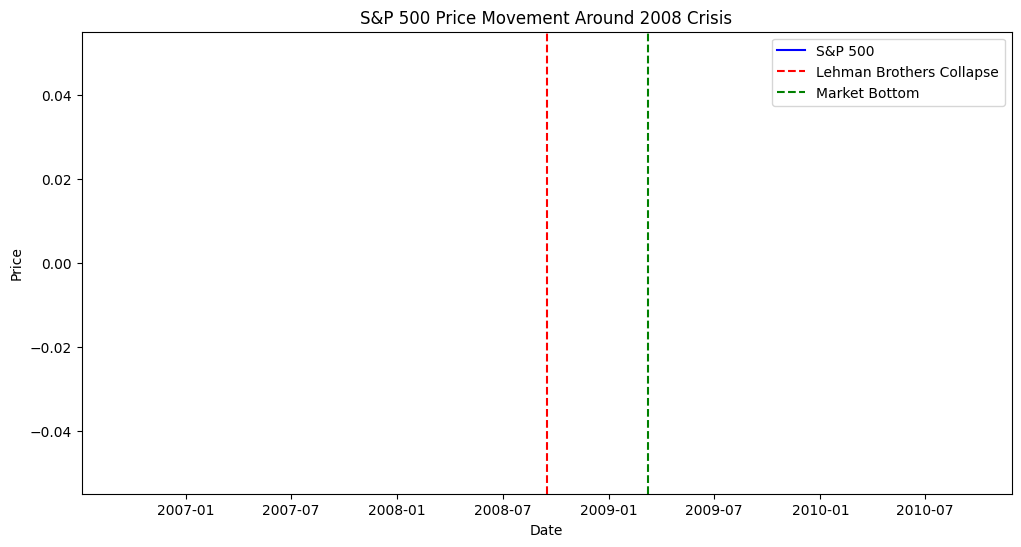

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Load S&P 500 data
df = pd.read_csv("/content/S&P 500 Historical Data.csv", parse_dates=['Date'], index_col='Date')

# Ensure the data is sorted by the Date column
df = df.sort_index()

# Focus on 2007–2010 to study the 2008 crash
df = df.loc['2007-01-01':'2010-12-31']

# Use the 'Price' column as the closing price
plt.figure(figsize=(12, 6))
plt.plot(df['Price'], label="S&P 500", color='b')
plt.axvline(pd.Timestamp("2008-09-15"), color='r', linestyle="--", label="Lehman Brothers Collapse")
plt.axvline(pd.Timestamp("2009-03-09"), color='g', linestyle="--", label="Market Bottom")
plt.legend()
plt.title("S&P 500 Price Movement Around 2008 Crisis")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [ ]:
# Remove commas from 'Price' and convert to float
df['Price'] = df['Price'].replace({',': ''}, regex=True).astype(float)

# Remove percentage signs from 'Change %' and convert to float
df['Change %'] = df['Change %'].replace({'%': ''}, regex=True).astype(float)

# Convert 'Date' to datetime format
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Now, let's check the cleaned dataframe
print(df.head())

        Date    Price      Open      High       Low  Vol.  Change %
0 2025-03-24  5767.57  5,718.08  5,775.14  5,718.08   NaN      1.76
1 2025-03-21  5667.56  5,630.73  5,670.84  5,603.10   NaN      0.08
2 2025-03-20  5662.89  5,646.92  5,711.15  5,632.33   NaN     -0.22
3 2025-03-19  5675.29  5,632.37  5,715.33  5,622.20   NaN      1.08
4 2025-03-18  5614.66  5,654.53  5,654.53  5,597.76   NaN     -1.07


**Structural Break Detection using Bai-Perron Test**

ADF Statistic (Differenced): -2.9676
p-value (Differenced): 0.0380


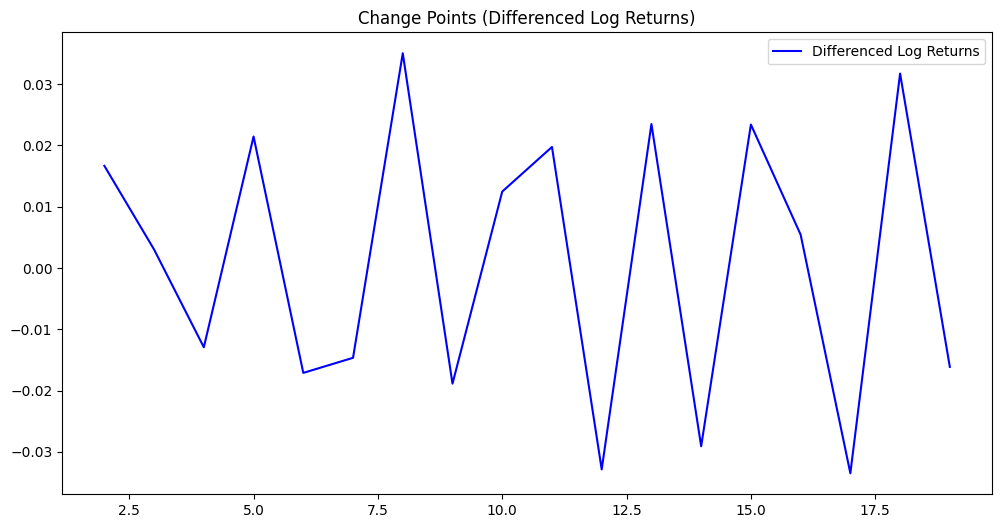

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from ruptures import Pelt, KernelCPD
import warnings

# Suppress runtime warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Compute differenced log returns
df['Log_Returns_Diff'] = df['Log_Returns'] - df['Log_Returns'].shift(1)
log_returns_diff_clean = df['Log_Returns_Diff'].dropna().astype('float64')

# Stationarity check on differenced series
adf_result_diff = adfuller(log_returns_diff_clean)
print(f"ADF Statistic (Differenced): {adf_result_diff[0]:.4f}")
print(f"p-value (Differenced): {adf_result_diff[1]:.4f}")

# Perform breakpoint detection on the differenced log returns
log_returns_diff_clean_values = log_returns_diff_clean.values
try:
    algo = Pelt(model='rbf', min_size=5).fit(log_returns_diff_clean_values)
    breakpoints = algo.predict(pen=5)

    # Plot the change points for differenced log returns
    plt.figure(figsize=(12, 6))
    plt.plot(log_returns_diff_clean, label="Differenced Log Returns", color='b')
    for bp in breakpoints[:-1]:  # Exclude the last point (end of series)
        plt.axvline(log_returns_diff_clean.index[bp], color='r', linestyle="--")
    plt.title("Change Points (Differenced Log Returns)")
    plt.legend()
    plt.show()

except Exception as e:
    print(f"Error in breakpoint detection: {str(e)}")


**Markov Switching Model for Regime Changes**

Iteration:      1,   Func. Count:      7,   Neg. LLF: 81.88505341245543
Iteration:      2,   Func. Count:     15,   Neg. LLF: 76.35307368920546
Iteration:      3,   Func. Count:     21,   Neg. LLF: 76.35305931078537
Iteration:      4,   Func. Count:     27,   Neg. LLF: 76.35303000204942
Iteration:      5,   Func. Count:     33,   Neg. LLF: 76.35302347946492
Iteration:      6,   Func. Count:     38,   Neg. LLF: 76.35302347941455
Optimization terminated successfully    (Exit mode 0)
            Current function value: 76.35302347946492
            Iterations: 6
            Function evaluations: 38
            Gradient evaluations: 6
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -76.3530
Distribution:                  Normal   AIC: 

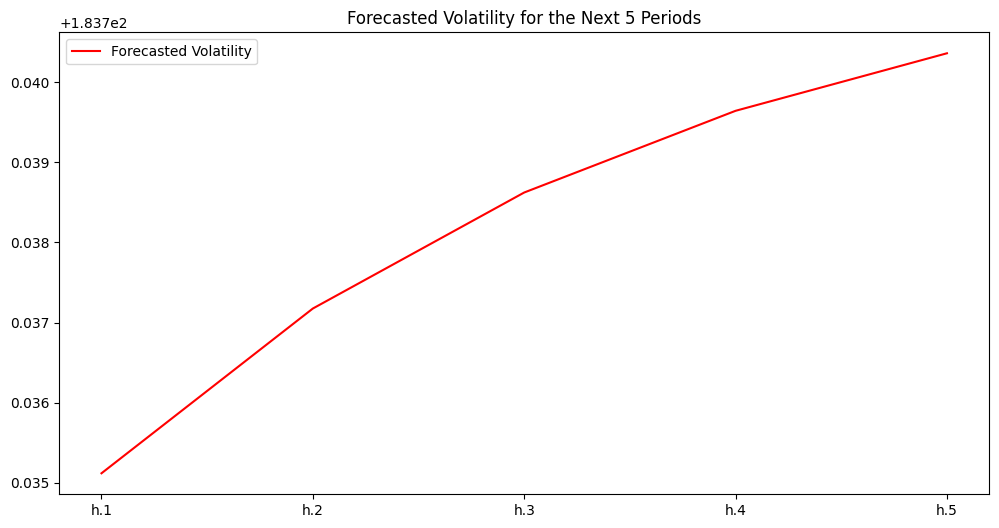

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from arch import arch_model

# Assuming df is your DataFrame and 'Log_Returns' is the column with your log returns
returns = df['Log_Returns'].dropna()

# Fit a GARCH(1, 1) model
returns_rescaled = returns * 1000  # Scale by 1000 or another factor
model = arch_model(returns_rescaled, vol='Garch', p=2, q=1)
results = model.fit()

# Print the model summary
print(results.summary())

# Forecast volatility for the next 5 periods
forecast = results.forecast(horizon=5)

# Plot the forecasted volatility
plt.figure(figsize=(12, 6))
plt.plot(forecast.variance.iloc[-1, :], label="Forecasted Volatility", color='red')
plt.title("Forecasted Volatility for the Next 5 Periods")
plt.legend()
plt.show()

In [ ]:
from arch import arch_model

# Fit a GARCH(1, 1) model (as per your example)
returns_rescaled = df['Log_Returns'].dropna() * 1000  # Rescale if necessary
model = arch_model(returns_rescaled, vol='Garch', p=1, q=1)
results = model.fit()

# Print summary
print(results.summary())

# Forecast volatility
forecast = results.forecast(horizon=5)
print(forecast.variance[-1:])

Iteration:      1,   Func. Count:      6,   Neg. LLF: 81.88517705251056
Iteration:      2,   Func. Count:     13,   Neg. LLF: 76.35307681136482
Iteration:      3,   Func. Count:     18,   Neg. LLF: 76.35306435712323
Iteration:      4,   Func. Count:     23,   Neg. LLF: 76.35302387006452
Iteration:      5,   Func. Count:     27,   Neg. LLF: 76.35302386995633
Optimization terminated successfully    (Exit mode 0)
            Current function value: 76.35302387006452
            Iterations: 5
            Function evaluations: 27
            Gradient evaluations: 5
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Log_Returns   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -76.3530
Distribution:                  Normal   AIC:                           160.706
Method:            Maximum Likelihood 

**Check for Stationarity using Augmented Dickey-Fuller (ADF) Test**

In [ ]:
def adf_test(series):
    try:
        # Remove NaN and Inf values
        series_clean = series.replace([np.inf, -np.inf], np.nan).dropna()

        # Perform ADF test
        result = adfuller(series_clean)
        print(f'ADF Statistic: {result[0]}')
        print(f'p-value: {result[1]}')
        if result[1] > 0.05:
            print("Series is Non-Stationary")
        else:
            print("Series is Stationary")
    except KeyError:
        print("The specified column does not exist in the DataFrame.")
    except Exception as e:
        print(f"An error occurred: {e}")

adf_test(df['Log_Returns'])

ADF Statistic: -1.9475903228082887
p-value: 0.31001468577270985
Series is Non-Stationary


**First Difference the Data**

ADF Statistic: -1.9300185959405798
p-value: 0.3180738236091122
Series is Non-Stationary


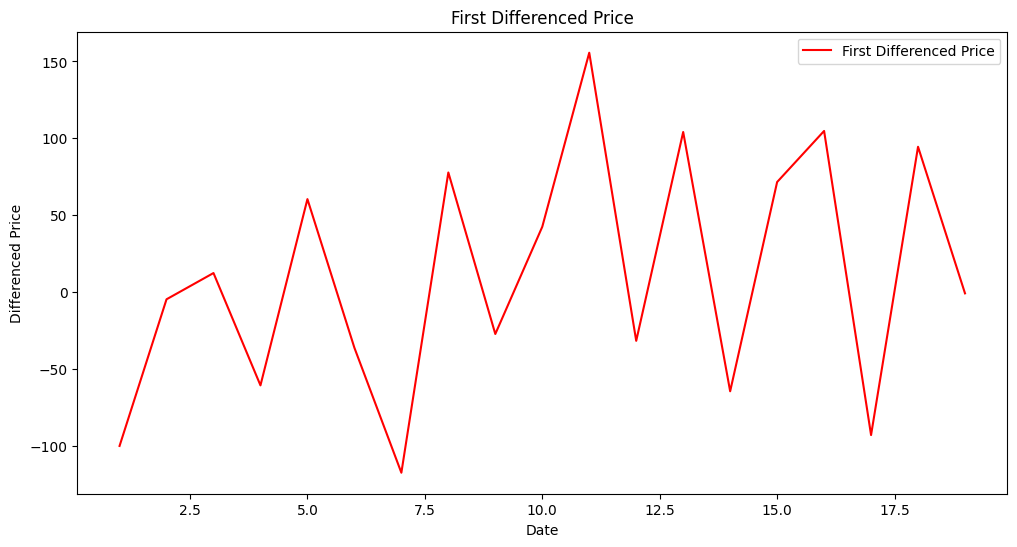

In [ ]:
df['Price_diff'] = df['Price'].diff()  # Compute first differences

# Re-run ADF test
adf_test(df['Price_diff'].dropna())

# Plot differenced Price
plt.figure(figsize=(12, 6))
plt.plot(df['Price_diff'], label="First Differenced Price", color='r')
plt.title("First Differenced Price")
plt.xlabel("Date")
plt.ylabel("Differenced Price")
plt.legend()
plt.show()

**Cointegration Test using GDP and Unemployment Level**

In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import coint

# Load GDP Data with the correct date column
gdp_df = pd.read_csv("/content/GDPC1.csv", parse_dates=['observation_date'], index_col='observation_date')
print("GDP Data Loaded:")
print(gdp_df.head())

# Load Unemployment Data
unemployment_df = pd.read_csv("/content/UNEMPLOY.csv", parse_dates=['observation_date'], index_col='observation_date')
print("Unemployment Data Loaded:")
print(unemployment_df.head())

# Ensure unemployment column name is correct
if 'UNEMPLOY' in unemployment_df.columns:
    unemployment_df.rename(columns={'UNEMPLOY': 'Unemployment'}, inplace=True)

# Merge both datasets using the date index
df = gdp_df.join(unemployment_df, how="inner")

# Rename GDP column if necessary
if 'GDPC1' in df.columns:
    df.rename(columns={'GDPC1': 'GDP'}, inplace=True)

# Check final column names
print("Columns after merging:", df.columns)

# Ensure 'GDP' and 'Unemployment' exist
if 'GDP' not in df.columns or 'Unemployment' not in df.columns:
    raise ValueError("One or more required columns are missing. Check the loaded data.")

# Drop rows with NaN values
df.dropna(subset=['GDP', 'Unemployment'], inplace=True)

# Perform Cointegration Test
coint_t, p_value, _ = coint(df['GDP'], df['Unemployment'])
print(f"Cointegration Test p-value: {p_value}")

if p_value < 0.05:
    print("The two series are cointegrated")
else:
    print("No cointegration detected")

GDP Data Loaded:
                     GDPC1
observation_date          
1947-01-01        2182.681
1947-04-01        2176.892
1947-07-01        2172.432
1947-10-01        2206.452
1948-01-01        2239.682
Unemployment Data Loaded:
                  UNEMPLOY
observation_date          
1948-01-01            2034
1948-02-01            2328
1948-03-01            2399
1948-04-01            2386
1948-05-01            2118
Columns after merging: Index(['GDP', 'Unemployment'], dtype='object')
Cointegration Test p-value: 0.7743968285353857
No cointegration detected


**Vector Autoregression (VAR) Model**

In [ ]:
import pandas as pd
from statsmodels.tsa.api import VAR

# Ensure 'Date' index is a DateTime index with the correct frequency
df.index = pd.DatetimeIndex(df.index).to_period('Q')  # 'Q' for quarterly data

# Compute first difference of GDP
df['GDP_diff'] = df['GDP'].diff()

# Prepare the data for VAR (drop NaNs after differencing)
df_var = df[['GDP_diff', 'Unemployment']].dropna()

# Fit VAR model
model = VAR(df_var)
results = model.fit(maxlags=4, ic='aic')  # Choose lag based on AIC criterion

# Forecast the next 5 periods
forecast = results.forecast(df_var.values[-4:], steps=5)

# Print results
print(forecast)

[[ 119.72455837 6649.47951275]
 [  77.0568809  6585.18673532]
 [  75.39901769 6588.89773886]
 [  73.39281441 6575.51054047]
 [  69.81557442 6586.53067399]]


**Error Correction Model (ECM)**

In [ ]:
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# Load and merge datasets (adjusting the column names for the GDP dataset)
df = pd.read_csv("/content/GDPC1.csv", parse_dates=['observation_date'], index_col='observation_date')
unemployment_df = pd.read_csv("/content/UNEMPLOY.csv", parse_dates=['observation_date'], index_col='observation_date')

# Merge datasets
df = df.join(unemployment_df, how="inner")
df.dropna(inplace=True)

# Perform Johansen cointegration test
johansen_test = coint_johansen(df[['GDPC1', 'UNEMPLOY']], det_order=0, k_ar_diff=1)

# Display test results
print(johansen_test.lr1)  # Eigenvalue statistic
print(johansen_test.cvt)  # Critical values

# Analyze the results: check whether the test statistic exceeds the critical values

[64.00901209 10.71277586]
[[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]


**Regime changes in the S&P 500**

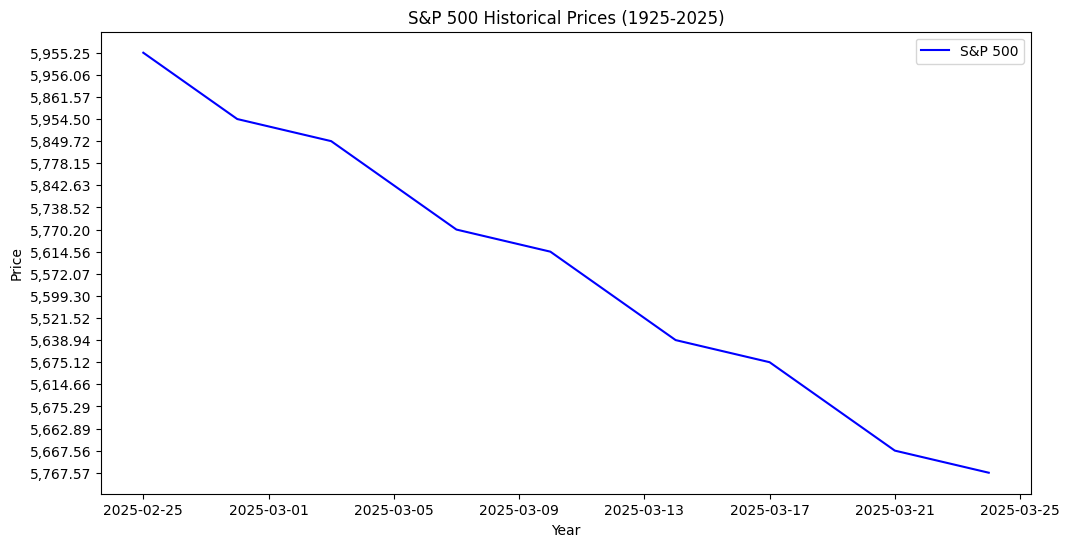

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# Load the dataset (assuming from Yahoo Finance or FRED)
df = pd.read_csv("/content/S&P 500 Historical Data.csv", parse_dates=['Date'], index_col='Date')

# Plot the S&P 500 data
plt.figure(figsize=(12,6))
plt.plot(df['Price'], label="S&P 500", color='b')
plt.title("S&P 500 Historical Prices (1925-2025)")
plt.xlabel("Year")
plt.ylabel("Price")
plt.legend()
plt.show()

**Identify Regime Changes through Structural Break Detection by using Bai-Perron test to detect multiple breakpoints**

[*********************100%***********************]  1 of 1 completed

Successfully downloaded data from Yahoo Finance

Data loaded successfully (1007 points from 2007-01-03 to 2010-12-30)
Found 91 breaks with pen=15


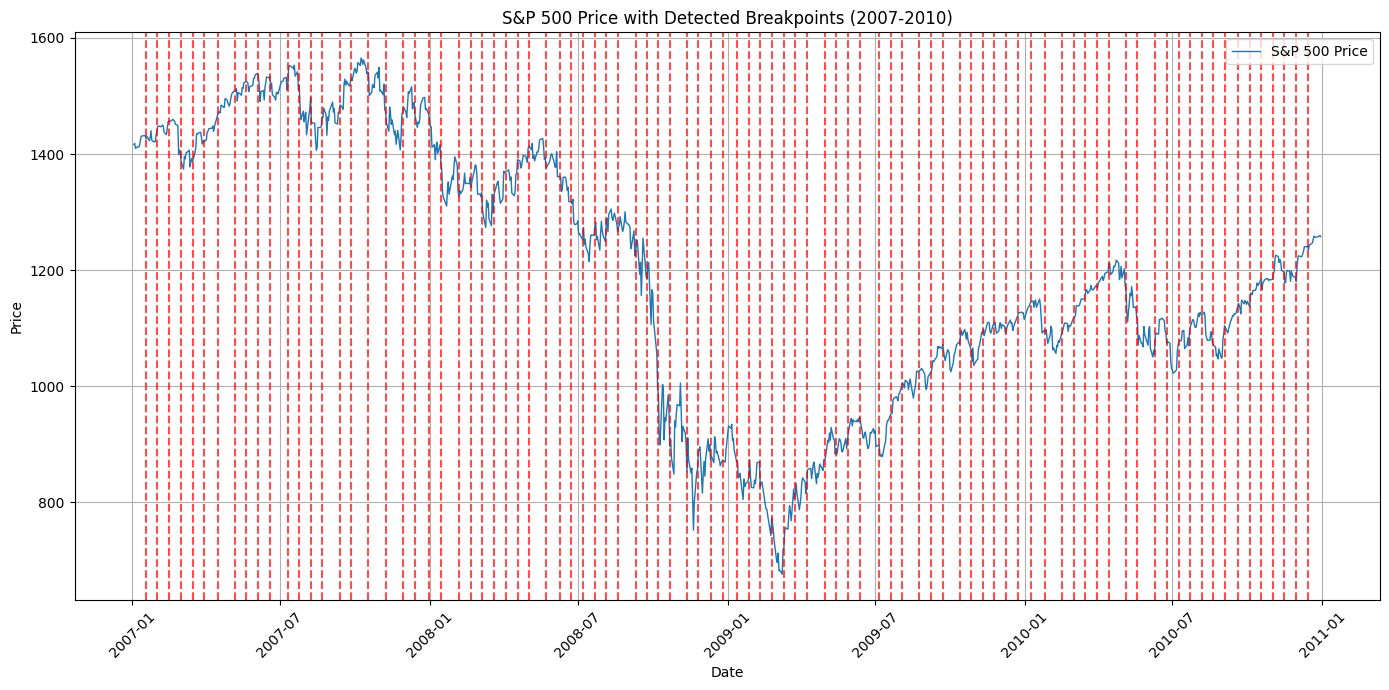


Key Breakpoint Dates:
1. 2007-01-18
2. 2007-02-01
3. 2007-02-15
4. 2007-03-02
5. 2007-03-16
6. 2007-03-30
7. 2007-04-16
8. 2007-05-07
9. 2007-05-21
10. 2007-06-05
11. 2007-06-19
12. 2007-07-11
13. 2007-07-25
14. 2007-08-08
15. 2007-08-22
16. 2007-09-13
17. 2007-09-27
18. 2007-10-18
19. 2007-11-08
20. 2007-11-30
21. 2007-12-14
22. 2007-12-31
23. 2008-01-15
24. 2008-02-06
25. 2008-02-21
26. 2008-03-06
27. 2008-03-20
28. 2008-04-04
29. 2008-04-18
30. 2008-05-02
31. 2008-05-23
32. 2008-06-09
33. 2008-06-23
34. 2008-07-08
35. 2008-07-22
36. 2008-08-05
37. 2008-08-19
38. 2008-09-10
39. 2008-09-24
40. 2008-10-08
41. 2008-10-22
42. 2008-11-12
43. 2008-11-26
44. 2008-12-11
45. 2008-12-26
46. 2009-01-12
47. 2009-01-27
48. 2009-02-10
49. 2009-02-25
50. 2009-03-11
51. 2009-03-25
52. 2009-04-08
53. 2009-04-30
54. 2009-05-14
55. 2009-05-29
56. 2009-06-12
57. 2009-07-06
58. 2009-07-20
59. 2009-08-03
60. 2009-08-24
61. 2009-09-08
62. 2009-09-22
63. 2009-10-13
64. 2009-10-27
65. 2009-11-10
66. 2009-11

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import ruptures as rpt
import matplotlib.pyplot as plt
from datetime import datetime

def load_sp500_data(source='yahoo', filepath=None):
    """
    Load S&P 500 data from either Yahoo Finance or local CSV file

    Parameters:
    - source: 'yahoo' or 'csv'
    - filepath: Required if source='csv'

    Returns:
    - DataFrame with Price and Date columns
    """
    df = pd.DataFrame()

    if source == 'yahoo':
        try:
            print("Downloading data from Yahoo Finance...")
            df = yf.download("^GSPC", start="2007-01-01", end="2010-12-31")
            if df.empty:
                raise ValueError("No data downloaded")
            df['Price'] = df['Close']
            df['Date'] = df.index
            print("Successfully downloaded data from Yahoo Finance")
            return df[['Date', 'Price']]
        except Exception as e:
            print(f"Yahoo Finance download failed: {str(e)}")

    elif source == 'csv' and filepath:
        try:
            print(f"Loading data from CSV file: {filepath}")
            df = pd.read_csv(filepath)

            # Handle different column name possibilities
            price_col = next((col for col in ['Price', 'Close', 'Adj Close'] if col in df.columns), None)
            date_col = next((col for col in ['Date', 'Datetime'] if col in df.columns), None)

            if not price_col or not date_col:
                raise ValueError("Could not find required columns (Price/Close and Date)")

            df = df.rename(columns={price_col: 'Price', date_col: 'Date'})

            # Convert to datetime and sort
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date')
            df = df[['Date', 'Price']].dropna()

            print("Successfully loaded data from CSV")
            return df
        except Exception as e:
            print(f"CSV load failed: {str(e)}")

    return pd.DataFrame()

def detect_breakpoints(price_series, dates, model="l2", min_size=10, pen_values=[15, 10, 7, 5]):
    """
    Robust breakpoint detection with parameter tuning

    Returns:
    - List of breakpoint dates
    """
    price_data = price_series.values
    if len(price_data) < 2 * min_size:
        print(f"Not enough data ({len(price_data)} points) for min_size={min_size}")
        return []

    for pen in pen_values:
        try:
            algo = rpt.Pelt(model=model, min_size=min_size).fit(price_data)
            breakpoints = algo.predict(pen=pen)
            if len(breakpoints) > 2:
                print(f"Found {len(breakpoints)-1} breaks with pen={pen}")
                return [dates.iloc[bp] for bp in breakpoints[:-1]]  # Return dates
        except Exception as e:
            print(f"pen={pen} failed: {str(e)}")
    print("No valid breakpoints found")
    return []

# Try loading data - first from Yahoo, then from CSV if that fails
df = load_sp500_data(source='yahoo')

if df.empty:
    csv_path = "/content/S&P 500 Historical Data.csv"  # Update this path
    df = load_sp500_data(source='csv', filepath=csv_path)

if not df.empty:
    print(f"\nData loaded successfully ({len(df)} points from {df['Date'].iloc[0].date()} to {df['Date'].iloc[-1].date()})")

    # Detect breakpoints
    break_dates = detect_breakpoints(df['Price'], df['Date'])

    if break_dates:
        plt.figure(figsize=(14, 7))
        plt.plot(df['Date'], df['Price'], label='S&P 500 Price', linewidth=1)
        for bp_date in break_dates:
            plt.axvline(bp_date, color='red', linestyle='--', alpha=0.7)
        plt.title("S&P 500 Price with Detected Breakpoints (2007-2010)")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.grid(True)
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

        print("\nKey Breakpoint Dates:")
        for i, bp_date in enumerate(break_dates, 1):
            print(f"{i}. {bp_date.strftime('%Y-%m-%d')}")
    else:
        print("No significant breakpoints detected")
else:
    print("\nFailed to load data from all sources. Please check:")
    print("- Internet connection for Yahoo Finance")
    print("- CSV file path and format")
    print("Required CSV columns: 'Date' and either 'Price' or 'Close'")

**Hidden Markov Model (HMM) for Regime Switching (e.g., Bull vs. Bear markets)**

[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Fitting Markov Switching Model...


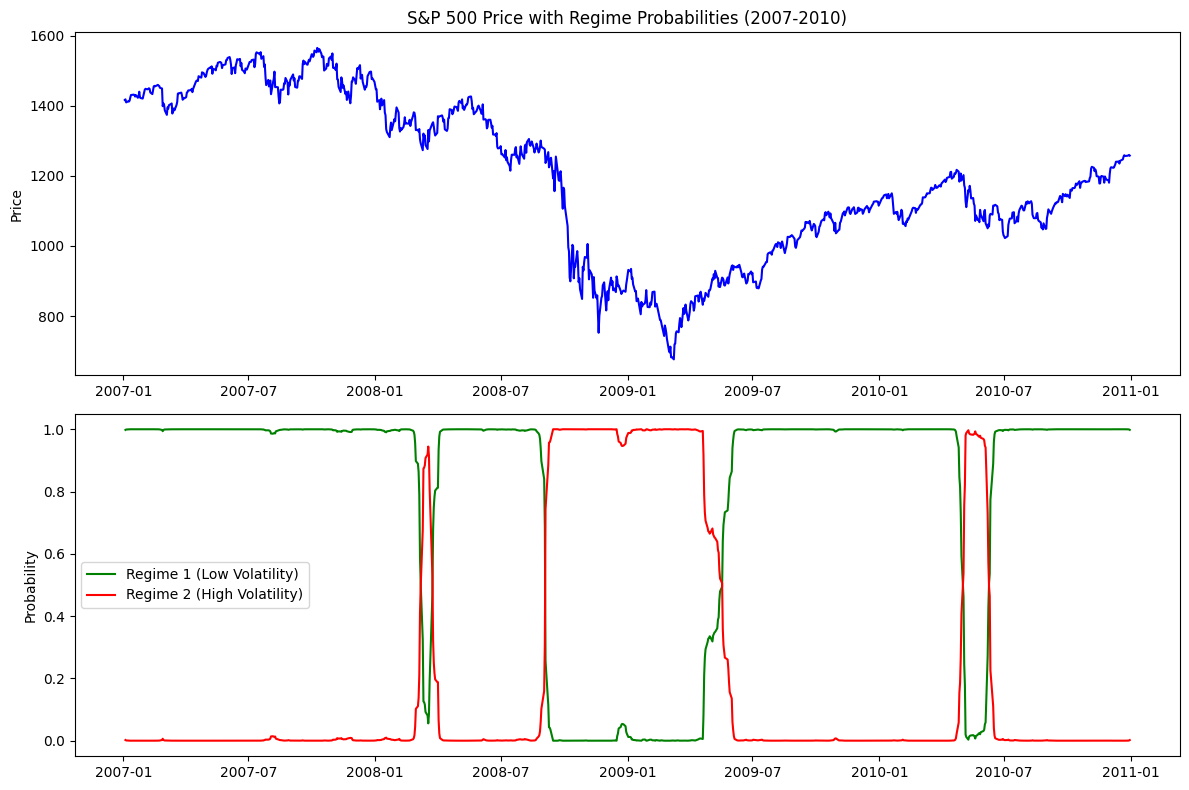


Model Summary:
                        Markov Switching Model Results                        
Dep. Variable:                  ^GSPC   No. Observations:                 1006
Model:               MarkovRegression   Log Likelihood                2878.769
Date:                Fri, 28 Mar 2025   AIC                          -5745.538
Time:                        14:35:39   BIC                          -5716.055
Sample:                             0   HQIC                         -5734.336
                               - 1006                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.174      0.240      -0.000       0.001
sigma2         0.0001   7.12e-06    

In [ ]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# 1. Load data properly
def load_data():
    try:
        # Download S&P 500 data
        df = yf.download("^GSPC", start="2007-01-01", end="2010-12-31")

        if df.empty:
            raise ValueError("No data downloaded")

        # Ensure we have required columns
        if 'Close' not in df.columns:
            raise ValueError("Data missing 'Close' column")

        return df

    except Exception as e:
        print(f"Error loading data: {str(e)}")
        return pd.DataFrame()

# 2. Load and prepare data
df = load_data()

if not df.empty:
    # Calculate returns
    returns = df['Close'].pct_change().dropna()

    # 3. Fit Markov Switching Model
    try:
        print("Fitting Markov Switching Model...")
        hmm_model = MarkovRegression(
            returns,
            k_regimes=2,
            trend='c',  # constant mean within each regime
            switching_variance=True  # allow variance to switch
        )
        hmm_fit = hmm_model.fit(disp=False)

        # 4. Plot results
        plt.figure(figsize=(12, 8))

        # Plot price series with regimes
        ax1 = plt.subplot(2, 1, 1)
        ax1.plot(df['Close'], label='S&P 500 Price', color='b')
        ax1.set_ylabel('Price')
        ax1.set_title('S&P 500 Price with Regime Probabilities (2007-2010)')

        # Plot regime probabilities
        ax2 = plt.subplot(2, 1, 2, sharex=ax1)
        ax2.plot(hmm_fit.smoothed_marginal_probabilities[0],
                label="Regime 1 (Low Volatility)", color='g')
        ax2.plot(hmm_fit.smoothed_marginal_probabilities[1],
                label="Regime 2 (High Volatility)", color='r')
        ax2.set_ylabel('Probability')
        ax2.legend()

        plt.tight_layout()
        plt.show()

        # Print model summary
        print("\nModel Summary:")
        print(hmm_fit.summary())

        # Correct parameter extraction using iloc
        params = hmm_fit.params

        print("\nRegime Characteristics:")
        print(f"Regime 0 (Low Volatility):")
        print(f"- Mean return: {params.iloc[0]:.6f} (const)")
        print(f"- Variance: {params.iloc[1]:.6f} (sigma2)")
        print(f"\nRegime 1 (High Volatility):")
        print(f"- Mean return: {params.iloc[2]:.6f} (const)")
        print(f"- Variance: {params.iloc[3]:.6f} (sigma2)")

        # Print transition probabilities
        print("\nTransition Probabilities:")
        print(f"P(Stay in Regime 0): {params.iloc[4]:.4f} (p[0->0])")
        print(f"P(Transition from Regime 1 to Regime 0): {params.iloc[5]:.4f} (p[1->0])")

        # Calculate implied probabilities
        p00 = params.iloc[4]
        p10 = params.iloc[5]
        p01 = 1 - p00
        p11 = 1 - p10

        print("\nFull Transition Matrix:")
        print(f"               | Regime 0 | Regime 1 |")
        print(f"------------------------------------")
        print(f"From Regime 0 | {p00:.4f}   | {p01:.4f}   |")
        print(f"From Regime 1 | {p10:.4f}   | {p11:.4f}   |")

        # Calculate steady-state probabilities
        pi0 = p10 / (p01 + p10)
        pi1 = p01 / (p01 + p10)
        print("\nSteady-State Probabilities:")
        print(f"P(Regime 0): {pi0:.4f}")
        print(f"P(Regime 1): {pi1:.4f}")

    except Exception as e:
        print(f"Error fitting model: {str(e)}")

else:
    print("No data available for analysis")

**Rolling Volatility Analysis**

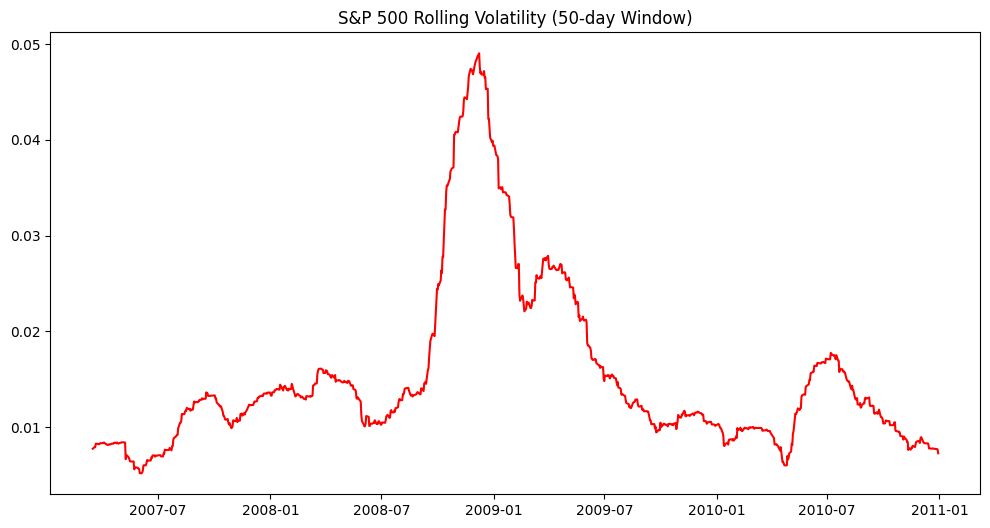

In [ ]:
# Compute rolling volatility
df['Volatility'] = df['Close'].pct_change().rolling(window=50).std()

# Plot volatility
plt.figure(figsize=(12,6))
plt.plot(df['Volatility'], label="Rolling Volatility", color='r')
plt.title("S&P 500 Rolling Volatility (50-day Window)")
plt.show()

**Detecting and Handling Multicollinearity in Economic Indicators Affecting Stock Prices**

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Final DataFrame shape: (2760, 5)
Date range: 2010-01-04 00:00:00 to 2020-12-30 00:00:00

First 5 rows:
                  SP500        Oil         Gold  ExchangeRate  StockPrice
Date                                                                     
2010-01-04  1132.989990  81.510002  1117.699951      1.442398    6.440332
2010-01-05  1136.520020  81.769997  1118.099976      1.436596    6.451467
2010-01-06  1137.140015  83.180000  1135.900024      1.440403    6.348845
2010-01-07  1141.689941  82.660004  1133.099976      1.431803    6.337109
2010-01-08  1144.979980  82.750000  1138.199951      1.441109    6.379240

Summary Statistics:
             SP500          Oil         Gold  ExchangeRate   StockPrice
count  2760.000000  2760.000000  2760.000000   2760.000000  2760.000000
mean   2076.149912    69.484772  1385.733116      1.223039    31.341967
std     674.466361    23.222467   214.400704      0.111778    24.430090
min    1022.580017   -37.630001  1050.800049      1.039047     5.77947

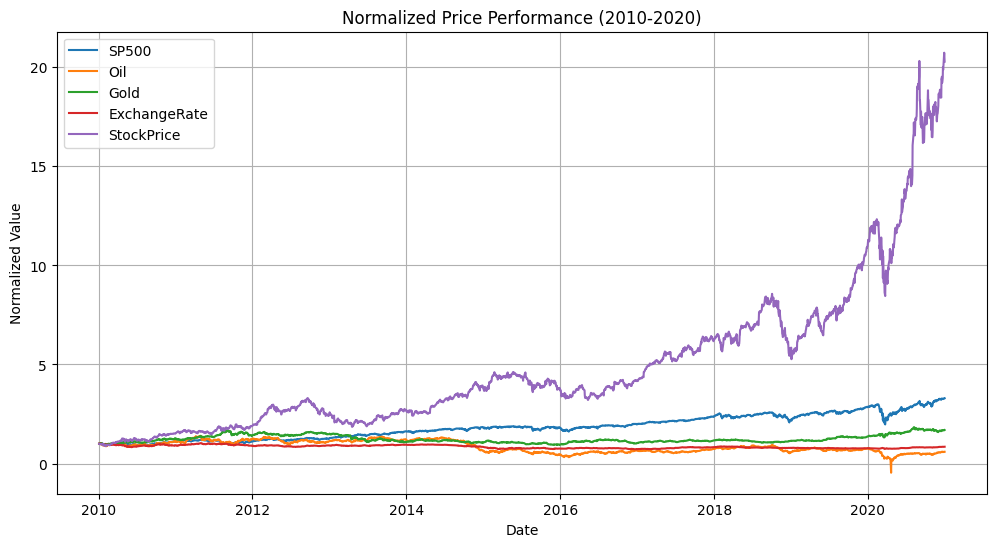

In [ ]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Fetch historical data
sp500 = yf.download('^GSPC', start='2010-01-01', end='2020-12-31')
oil = yf.download('CL=F', start='2010-01-01', end='2020-12-31')
gold = yf.download('GC=F', start='2010-01-01', end='2020-12-31')
exchange_rate = yf.download('EURUSD=X', start='2010-01-01', end='2020-12-31')
stock_price = yf.download('AAPL', start='2010-01-01', end='2020-12-31')

# Create a new DataFrame with aligned dates
df = pd.DataFrame(index=sp500.index)  # Use SP500 index as base

# Add each series to the DataFrame
df['SP500'] = sp500['Close']
df['Oil'] = oil['Close']
df['Gold'] = gold['Close']
df['ExchangeRate'] = exchange_rate['Close']
df['StockPrice'] = stock_price['Close']

# Drop any remaining NA values (just in case)
df = df.dropna()

# Show results
print(f"Final DataFrame shape: {df.shape}")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print("\nFirst 5 rows:")
print(df.head())

# Show summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Plot normalized prices
plt.figure(figsize=(12, 6))
for column in df.columns:
    plt.plot(df.index, df[column]/df[column].iloc[0], label=column)
plt.title('Normalized Price Performance (2010-2020)')
plt.ylabel('Normalized Value')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.show()

**Check for Multicollinearity by doing Correlation Matrix**

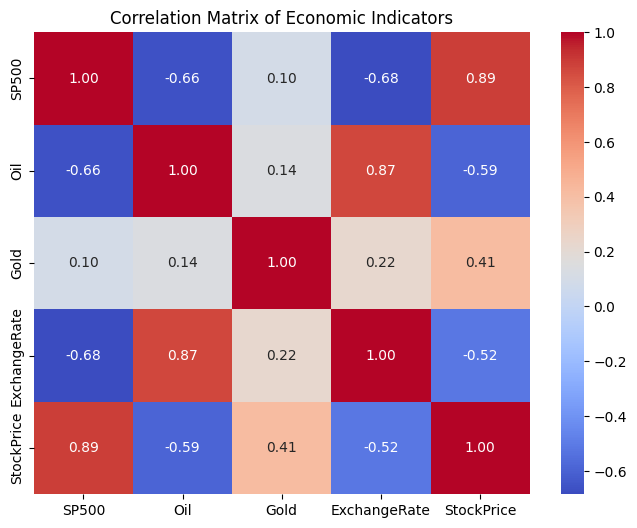

In [ ]:
# Compute correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Economic Indicators")
plt.show()

**Variance Inflation Factor (VIF)**

In [ ]:
# Compute VIF for each feature
X = df[['Oil', 'Gold', 'ExchangeRate', 'StockPrice', 'SP500']]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

        Feature         VIF
0           Oil   31.478223
1          Gold   90.759033
2  ExchangeRate  160.742798
3    StockPrice   20.576944
4         SP500   47.867060


**Address Multicollinearity by dropping One of the Correlated Variables**

In [ ]:
df = df.drop(columns=['Gold'])

**Perform Principal Component Analysis (PCA)**

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 uncorrelated components
X_pca = pca.fit_transform(X_scaled)

# Show explained variance
print(f"Explained Variance Ratio: {pca.explained_variance_ratio_}")

Explained Variance Ratio: [0.62285308 0.26881215]


**Feature Extraction in Time Series (Bitcoin Dataset)**

                            price    market_cap  total_volume
snapped_at                                                   
2013-04-28 00:00:00+00:00  135.30  1.500518e+09           0.0
2013-04-29 00:00:00+00:00  141.96  1.575032e+09           0.0
2013-04-30 00:00:00+00:00  135.30  1.501657e+09           0.0
2013-05-01 00:00:00+00:00  117.00  1.298952e+09           0.0
2013-05-02 00:00:00+00:00  103.43  1.148668e+09           0.0


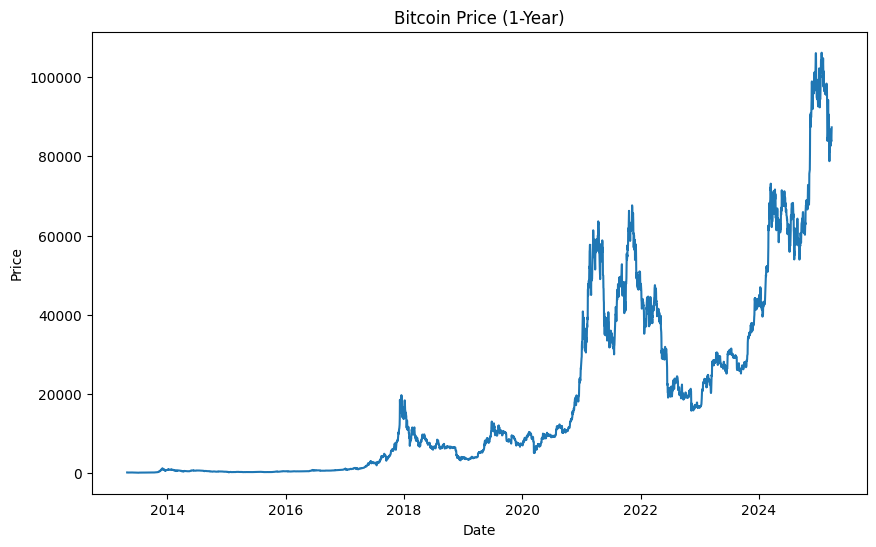

In [165]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the Bitcoin data with the correct column names
df = pd.read_csv("/content/btc-usd-max.csv", parse_dates=['snapped_at'], index_col='snapped_at')

# Show the first few rows
print(df.head())

# Plot the Bitcoin price data
plt.figure(figsize=(10,6))
plt.plot(df.index, df['price'])
plt.title("Bitcoin Price (1-Year)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

**Feature Extraction Techniques by Moving Averages (Trend Indicator)**

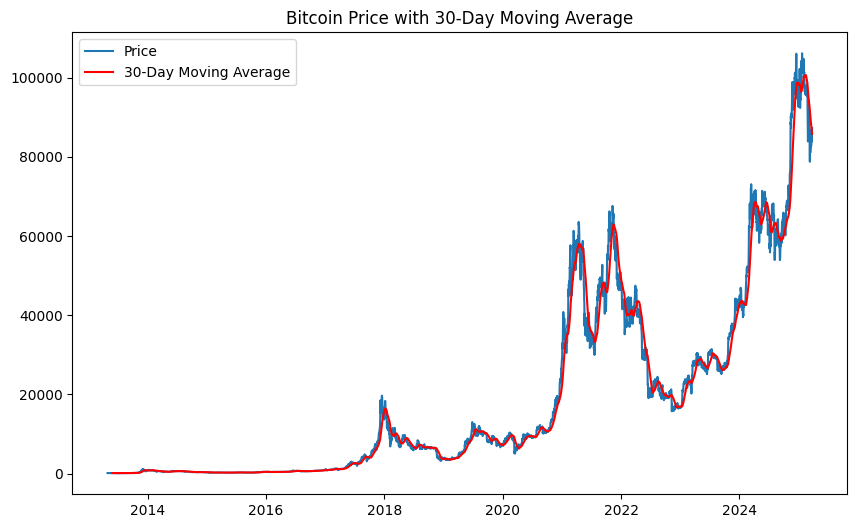

In [169]:
# Calculate 30-day moving average
# Calculate 30-day moving average
df['30_day_MA'] = df['price'].rolling(window=30).mean()

# Plot the moving average
plt.figure(figsize=(10,6))
plt.plot(df.index, df['price'], label="Price")
plt.plot(df.index, df['30_day_MA'], label="30-Day Moving Average", color='red')
plt.title("Bitcoin Price with 30-Day Moving Average")
plt.legend()
plt.show()

**Volatility (Standard Deviation of Returns)**

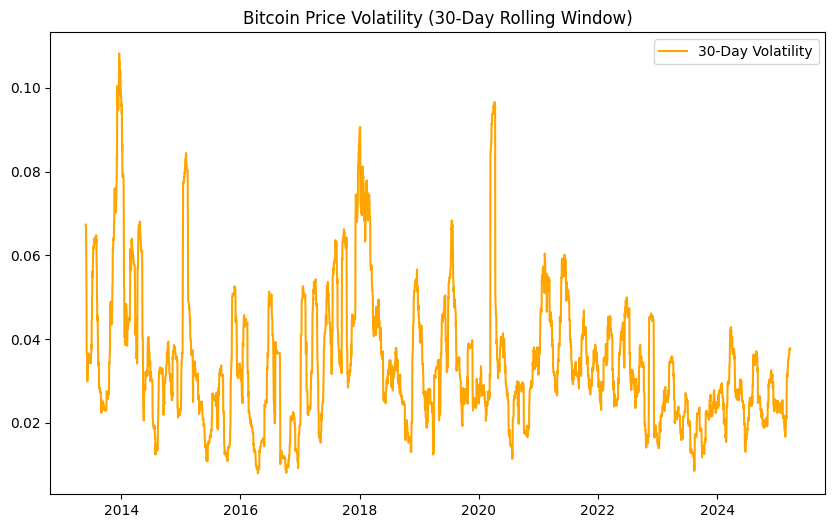

In [172]:
# Calculate daily returns (log returns)
df['Log_Ret'] = np.log(df['price'] / df['price'].shift(1))

# Calculate rolling standard deviation (volatility)
df['Volatility'] = df['Log_Ret'].rolling(window=30).std()

# Plot volatility
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Volatility'], label="30-Day Volatility", color='orange')
plt.title("Bitcoin Price Volatility (30-Day Rolling Window)")
plt.legend()
plt.show()

**Seasonality (Yearly or Monthly Patterns)**

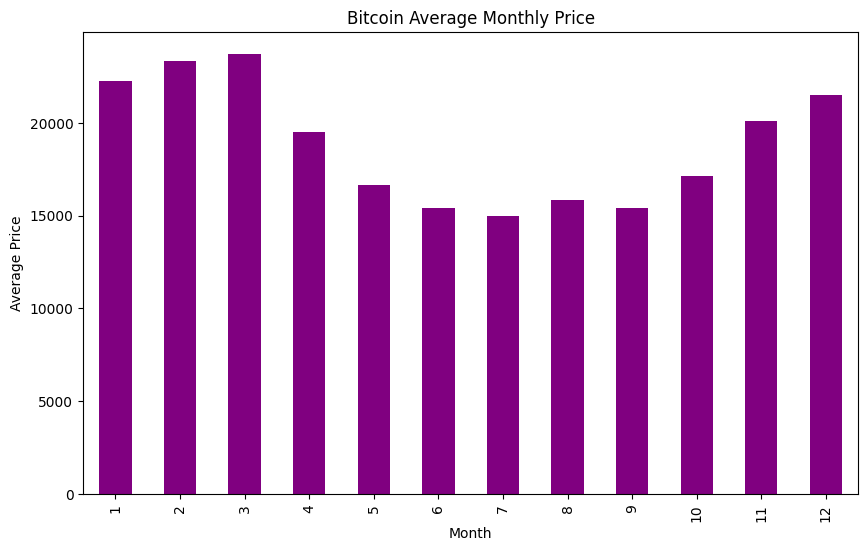

In [174]:
# Extract month from the Date to detect any monthly seasonality
df['Month'] = df.index.month

# Calculate average price per month
monthly_avg = df.groupby('Month')['price'].mean()

# Plot seasonality
plt.figure(figsize=(10,6))
monthly_avg.plot(kind='bar', color='purple')
plt.title("Bitcoin Average Monthly Price")
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

**Skewness & Kurtosis (Shape of the Distribution)**

In [177]:
from scipy.stats import skew, kurtosis

# Calculate skewness and kurtosis
skew_value = skew(df['price'].dropna())
kurt_value = kurtosis(df['price'].dropna())

print(f"Skewness: {skew_value}")
print(f"Kurtosis: {kurt_value}")

Skewness: 1.5066777486447207
Kurtosis: 1.6238924656781437


**Trend Features (Exponential Moving Average & Slope)**

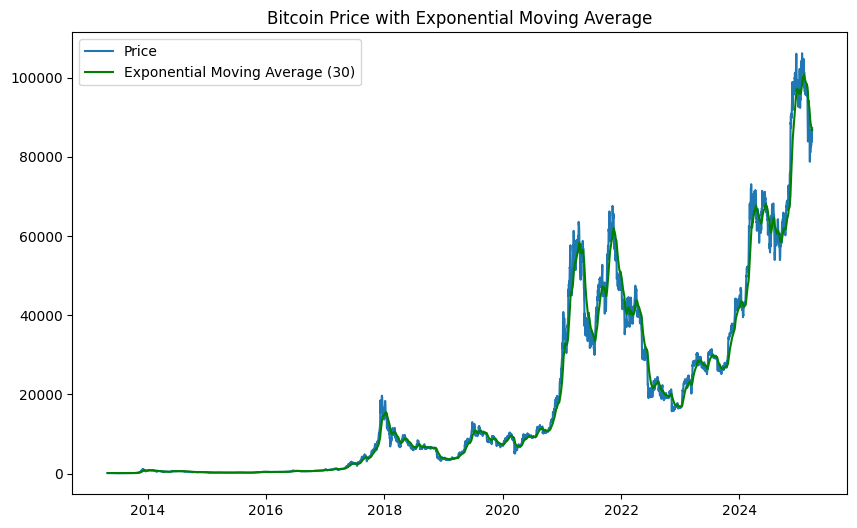

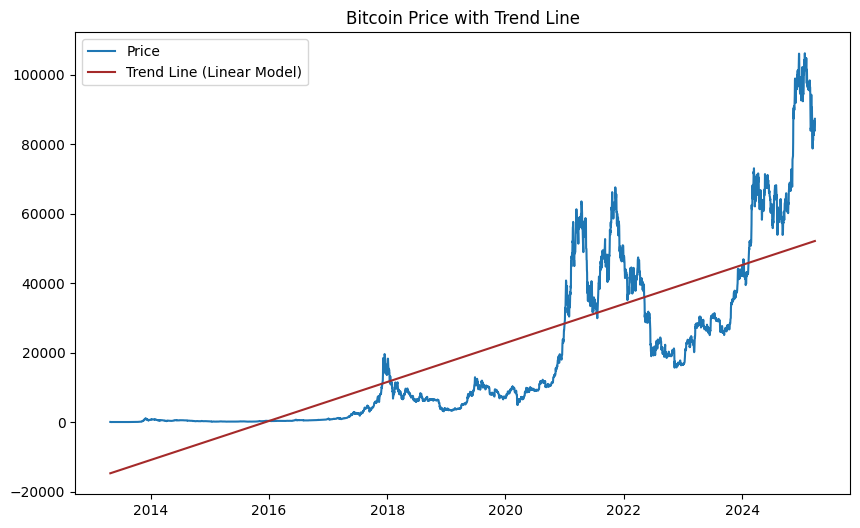

In [182]:
# Exponential moving average (EMA)
df['EMA'] = df['price'].ewm(span=30, adjust=False).mean()

# Plot EMA
plt.figure(figsize=(10,6))
plt.plot(df.index, df['price'], label="Price")
plt.plot(df.index, df['EMA'], label="Exponential Moving Average (30)", color='green')
plt.title("Bitcoin Price with Exponential Moving Average")
plt.legend()
plt.show()

# Fitting a linear model to capture the overall trend
from sklearn.linear_model import LinearRegression

# Create time variable (days since start)
df['Days'] = (df.index - df.index.min()).days

# Fit linear regression model
X = df[['Days']]
y = df['price']
model = LinearRegression().fit(X, y)
df['Trend'] = model.predict(X)

# Plot trend line
plt.figure(figsize=(10,6))
plt.plot(df.index, df['price'], label="Price")
plt.plot(df.index, df['Trend'], label="Trend Line (Linear Model)", color='brown')
plt.title("Bitcoin Price with Trend Line")
plt.legend()
plt.show()

**Combine Extracted Features into a Feature Set**

In [183]:
# Combine all extracted features into a new dataframe
features = df[['30_day_MA', 'Volatility', 'Month', 'EMA', 'Trend']].copy()

# Drop missing values (due to rolling windows)
features = features.dropna()

# Display the feature set
print(features.head())

                            30_day_MA  Volatility  Month         EMA  \
snapped_at                                                             
2013-05-28 00:00:00+00:00  119.729733    0.067328      5  124.377605   
2013-05-29 00:00:00+00:00  119.402067    0.066840      5  124.877759   
2013-05-30 00:00:00+00:00  119.138767    0.066599      5  125.040549   
2013-05-31 00:00:00+00:00  119.504767    0.060851      5  125.230191   
2013-06-01 00:00:00+00:00  120.360100    0.055984      6  125.479211   

                                  Trend  
snapped_at                               
2013-05-28 00:00:00+00:00 -14171.297436  
2013-05-29 00:00:00+00:00 -14155.934199  
2013-05-30 00:00:00+00:00 -14140.570962  
2013-05-31 00:00:00+00:00 -14125.207725  
2013-06-01 00:00:00+00:00 -14109.844487  


**Feature Extraction - Moving Averages and Volatility**

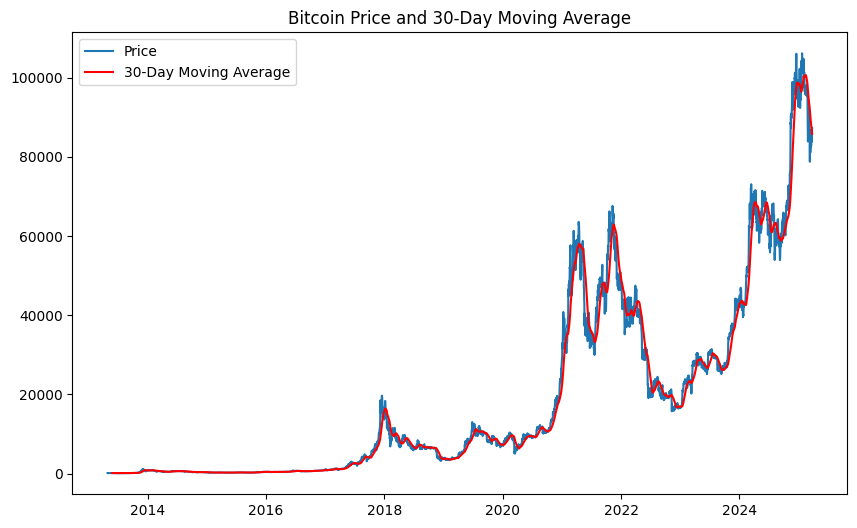

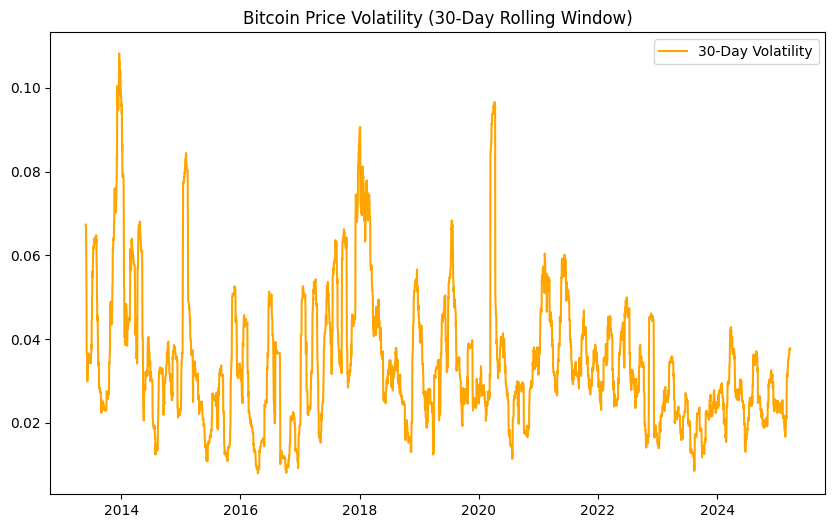

In [217]:
# Calculate 30-day moving average
df['30_day_MA'] = df['price'].rolling(window=30).mean()

# Calculate daily returns and volatility (standard deviation of returns)
df['Log_Ret'] = np.log(df['price'] / df['price'].shift(1))
df['Volatility'] = df['Log_Ret'].rolling(window=30).std()

# Plot the moving average and price data
plt.figure(figsize=(10,6))
plt.plot(df.index, df['price'], label="Price")
plt.plot(df.index, df['30_day_MA'], label="30-Day Moving Average", color='red')
plt.title("Bitcoin Price and 30-Day Moving Average")
plt.legend()
plt.show()

# Plot the volatility
plt.figure(figsize=(10,6))
plt.plot(df.index, df['Volatility'], label="30-Day Volatility", color='orange')
plt.title("Bitcoin Price Volatility (30-Day Rolling Window)")
plt.legend()
plt.show()

**Residual Plot (for Volatility Model)**

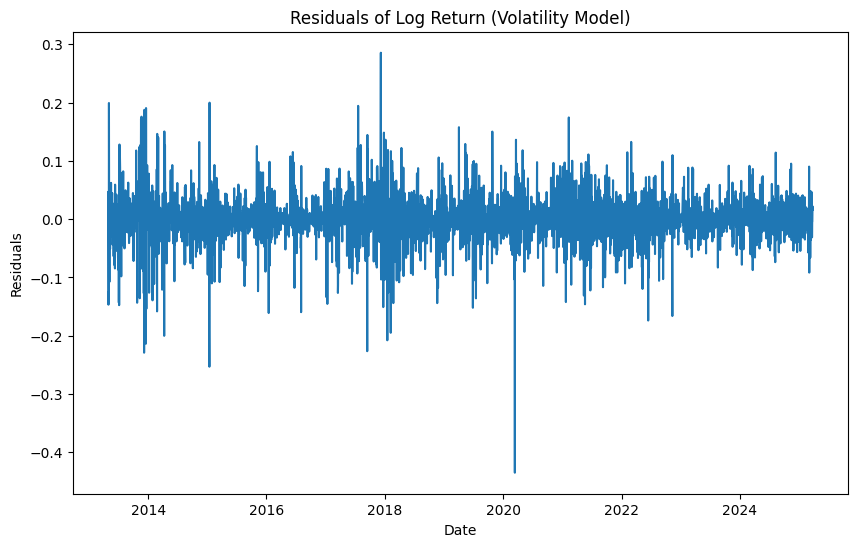

In [184]:
# Residual plot for volatility model
residuals = df['Log_Ret'] - df['Log_Ret'].mean()

plt.figure(figsize=(10,6))
plt.plot(df.index, residuals)
plt.title("Residuals of Log Return (Volatility Model)")
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

**Autocorrelation Plot (ACF/PACF)**

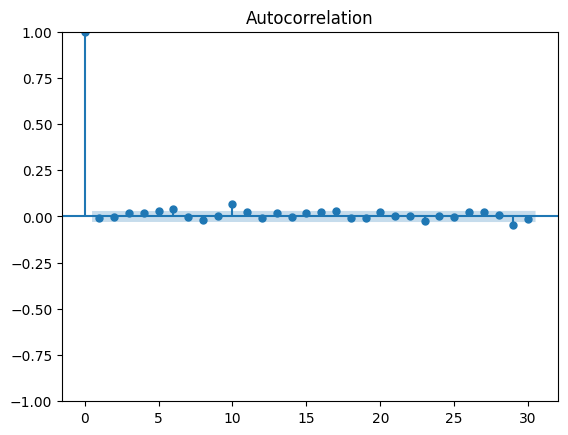

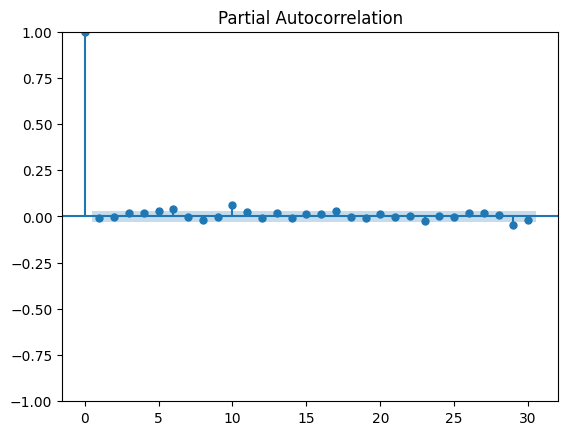

In [185]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots for log returns
plot_acf(df['Log_Ret'].dropna(), lags=30)
plot_pacf(df['Log_Ret'].dropna(), lags=30)
plt.show()

**Test for Unit Root using Augmented Dickey-Fuller Test**

In [187]:
from statsmodels.tsa.stattools import adfuller

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(df['price'].dropna())

# Print the ADF test results
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -0.3593436634825103
p-value: 0.9166688334625055


**Differencing the Series to Achieve Stationarity**

In [189]:
# First differencing the series
df['Price_diff'] = df['price'].diff()

# Perform ADF test on differenced series
adf_result_diff = adfuller(df['Price_diff'].dropna())

print("ADF Statistic (Differenced):", adf_result_diff[0])
print("p-value (Differenced):", adf_result_diff[1])

ADF Statistic (Differenced): -9.87749196196628
p-value (Differenced): 3.8477473888259587e-17


**Cointegration Test for Multiple Series**

In [197]:
import yfinance as yf
import pandas as pd
from statsmodels.tsa.vector_ar.vecm import coint_johansen

# 1. Prepare Gold Data
gold = yf.download('GC=F', start='2013-04-28', end='2020-12-30')  # Match Bitcoin's range
gold = gold[['Close']].copy()
gold.columns = ['Gold_Price']
gold.index = gold.index.tz_localize(None)  # Remove timezone

# 2. Prepare Bitcoin Data
btc = df[['price']].copy()
btc.columns = ['BTC_Price']
btc.index = pd.to_datetime(btc.index).tz_localize(None)  # Remove UTC timezone

# 3. Align date ranges
start_date = max(btc.index.min(), gold.index.min())
end_date = min(btc.index.max(), gold.index.max())
btc = btc.loc[start_date:end_date]
gold = gold.loc[start_date:end_date]

# 4. Merge data
df_combined = pd.concat([btc, gold], axis=1).dropna()

print("\nCombined Data Summary:")
print(f"Date range: {df_combined.index.min()} to {df_combined.index.max()}")
print(f"Observations: {len(df_combined)}")
print(df_combined.head())

# 5. Johansen Test
try:
    result = coint_johansen(df_combined, det_order=0, k_ar_diff=1)

    print("\nCointegration Results:")
    print("Eigenvalues:", result.eig)
    print("Trace Stats:", result.lr1)
    print("Critical Values (90%, 95%, 99%):")
    for i, cv in enumerate(result.cvt.T):
        print(f"{['90%', '95%', '99%'][i]}: {cv}")

except Exception as e:
    print(f"Test failed: {str(e)}")

[*********************100%***********************]  1 of 1 completed


Combined Data Summary:
Date range: 2013-04-29 00:00:00 to 2020-12-29 00:00:00
Observations: 1924
            BTC_Price   Gold_Price
2013-04-29     141.96  1467.400024
2013-04-30     135.30  1472.199951
2013-05-01     117.00  1446.300049
2013-05-02     103.43  1467.699951
2013-05-03      91.01  1464.300049

Cointegration Results:
Eigenvalues: [0.00508879 0.00207924]
Trace Stats: [13.80608211  4.00046546]
Critical Values (90%, 95%, 99%):
90%: [13.4294  2.7055]
95%: [15.4943  3.8415]
99%: [19.9349  6.6349]


**Error Correction Model (ECM)**

In [198]:
from statsmodels.tsa.vector_ar.vecm import VECM

# Fit the VECM model to the data
vecm = VECM(df_combined, k_ar_diff=1, coint_rank=1)
vecm_fit = vecm.fit()

# Print the model summary
print(vecm_fit.summary())

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation BTC_Price
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.BTC_Price     -0.0269      0.023     -1.178      0.239      -0.072       0.018
L1.Gold_Price     2.0947      0.546      3.839      0.000       1.025       3.164
Det. terms outside the coint. relation & lagged endog. parameters for equation Gold_Price
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
L1.BTC_Price      0.0007      0.001      0.727      0.467      -0.001       0.003
L1.Gold_Price    -0.0522      0.023     -2.290      0.022      -0.097      -0.008
             Loading coefficients (alpha) for equation BTC_Price              
                 coef    std err          z      P>|z|      [0.025      0.975]
-------

**Residual Plot of ECM Model**

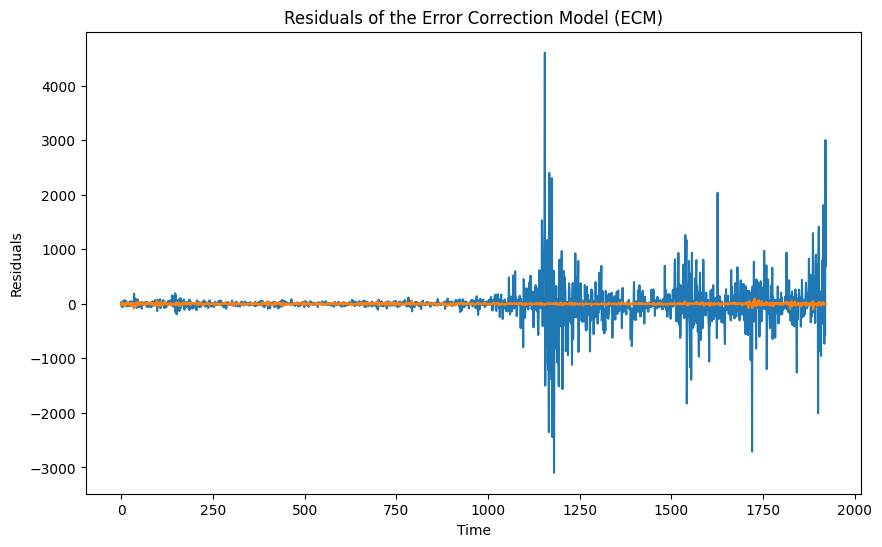

In [199]:
# Residuals of the VECM model
residuals = vecm_fit.resid

# Plot residuals
plt.figure(figsize=(10,6))
plt.plot(residuals)
plt.title("Residuals of the Error Correction Model (ECM)")
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.show()

**Extract Features by Rolling Mean (Moving Average)**

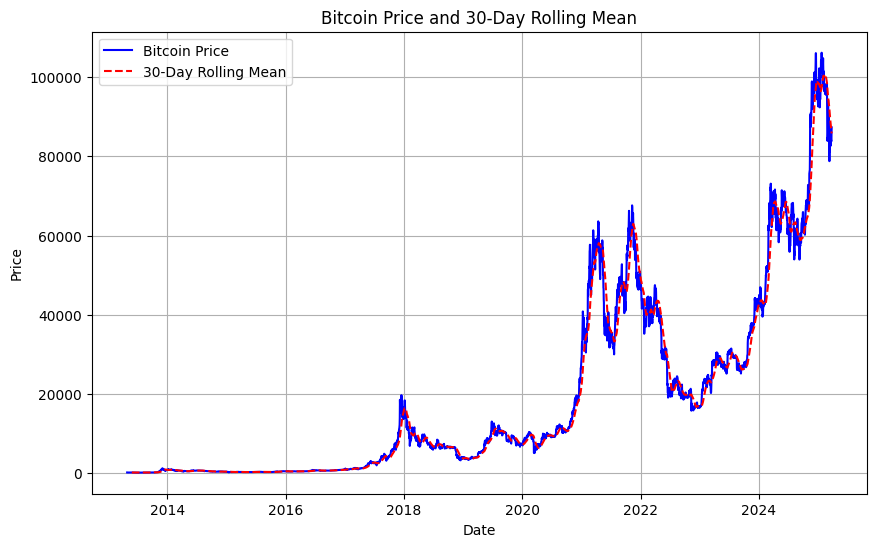

In [201]:
import matplotlib.pyplot as plt

# Calculate rolling mean - use whichever column name you have ('price' or 'BTC_Price')
price_column = 'price' if 'price' in df.columns else 'BTC_Price'
df['Rolling_Mean'] = df[price_column].rolling(window=30).mean()

# Plot
plt.figure(figsize=(10,6))
plt.plot(df[price_column], label='Bitcoin Price', color='blue')
plt.plot(df['Rolling_Mean'], label='30-Day Rolling Mean', color='red', linestyle='--')
plt.title("Bitcoin Price and 30-Day Rolling Mean")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

**Volatility (Rolling Standard Deviation)**

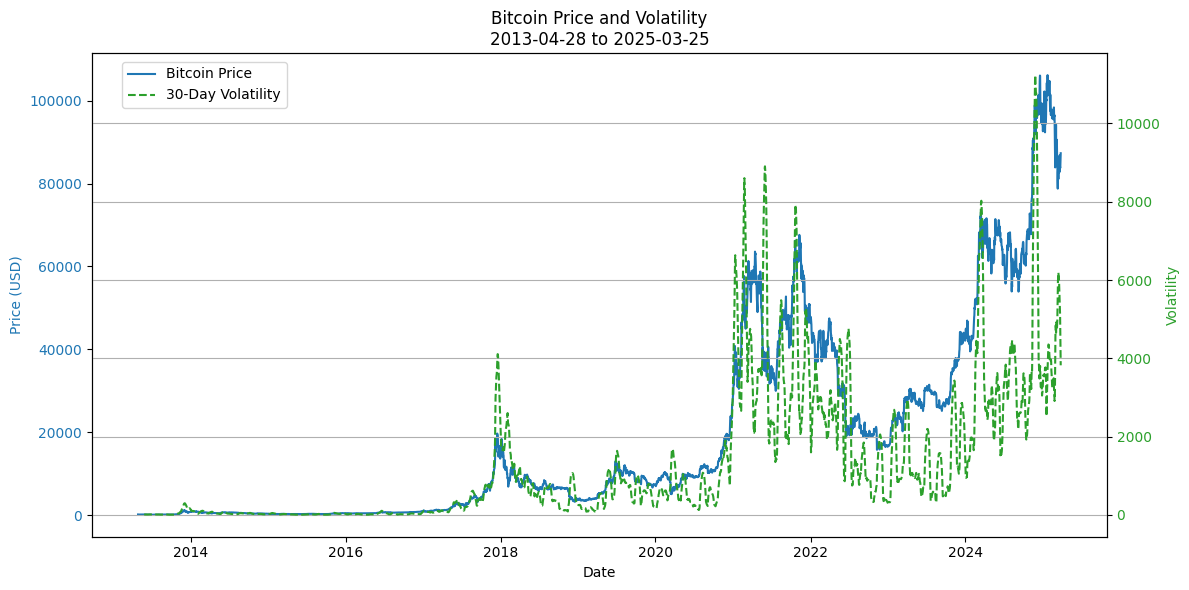


Volatility Statistics:
count     4319.000000
mean      1254.198166
std       1702.869790
min          3.219747
25%         45.072134
50%        546.935192
75%       1943.067383
max      11234.395952
Name: Volatility, dtype: float64


In [206]:
import matplotlib.pyplot as plt

# Calculate 30-day rolling standard deviation (volatility)
df['Volatility'] = df['price'].rolling(window=30).std()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Bitcoin price on primary axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Price (USD)', color=color)
ax1.plot(df.index, df['price'], color=color, label='Bitcoin Price')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis for volatility
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Volatility', color=color)
ax2.plot(df.index, df['Volatility'], color=color, linestyle='--', label='30-Day Volatility')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title(f"Bitcoin Price and Volatility\n{df.index.min().date()} to {df.index.max().date()}")
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))

# Formatting
plt.grid(True)
plt.tight_layout()
plt.show()

# Summary statistics of the calculated volatility
print("\nVolatility Statistics:")
print(df['Volatility'].describe())

**Rate of Change (RoC)**

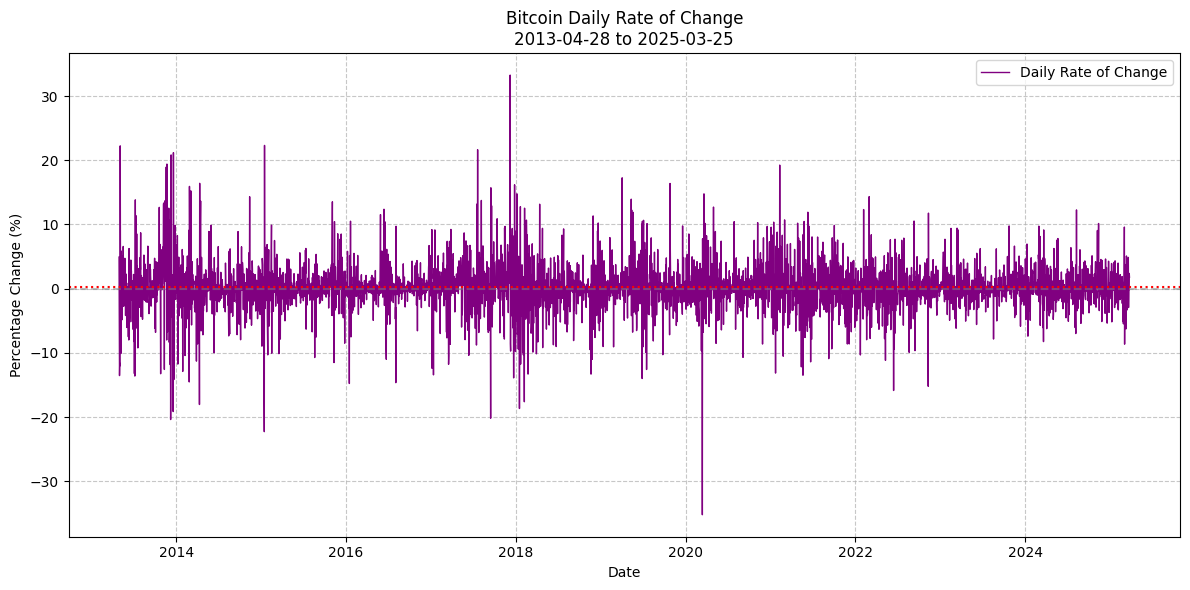


Rate of Change Statistics:
Maximum daily gain: 33.26%
Maximum daily loss: -35.19%
Average daily change: 0.22%
Standard deviation: 3.83%


In [208]:
import matplotlib.pyplot as plt

# Calculate daily Rate of Change (percentage change)
df['RoC'] = df['price'].pct_change() * 100  # Using 'price' column instead of 'Close'

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['RoC'], label="Daily Rate of Change", color='purple', linewidth=1)

# Add horizontal line at zero for reference
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)

# Add plot elements
plt.title(f"Bitcoin Daily Rate of Change\n{df.index.min().date()} to {df.index.max().date()}")
plt.xlabel("Date")
plt.ylabel("Percentage Change (%)")
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.7)

# Add some statistics to the plot
mean_roc = df['RoC'].mean()
plt.axhline(y=mean_roc, color='red', linestyle=':', label=f'Mean RoC: {mean_roc:.2f}%')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nRate of Change Statistics:")
print(f"Maximum daily gain: {df['RoC'].max():.2f}%")
print(f"Maximum daily loss: {df['RoC'].min():.2f}%")
print(f"Average daily change: {df['RoC'].mean():.2f}%")
print(f"Standard deviation: {df['RoC'].std():.2f}%")

**Autocorrelation**

<Figure size 1200x600 with 0 Axes>

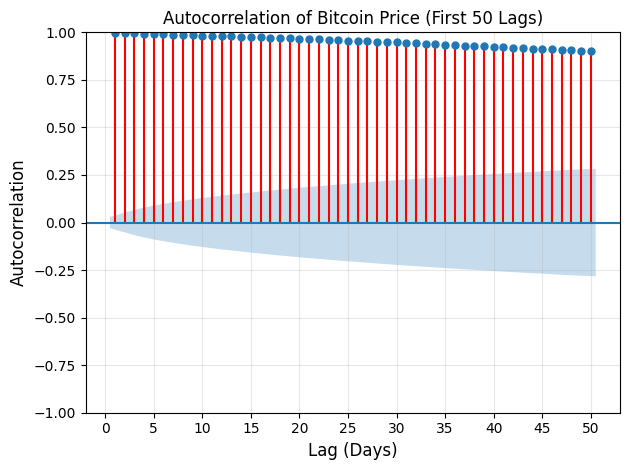

Plot saved as bitcoin_acf.png

Detailed ACF Interpretation:
1. Blue shaded area = 95% confidence interval for null hypothesis (no autocorrelation)
2. Bars extending above blue region = significant positive autocorrelation
3. Bars extending below blue region = significant negative autocorrelation
4. Slow decay pattern = strong trend/persistence in prices
5. Sharp cutoff after lag 1 = short-term momentum
6. Alternating positive/negative = possible mean-reversion
7. Seasonal spikes (e.g., every 7 lags) = weekly patterns

Practical Implications:
- High autocorrelation suggests past prices predict future prices
- Low autocorrelation suggests random walk behavior
- Trading strategies can exploit these patterns if they exist


<Figure size 640x480 with 0 Axes>

In [211]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Create figure before plotting
plt.figure(figsize=(12, 6))

# Plot ACF with proper parameters
plot_acf(df['price'].dropna(),
         lags=50,
         alpha=0.05,
         title='Autocorrelation of Bitcoin Price (First 50 Lags)',
         zero=False,  # Don't show lag 0 correlation (always 1)
         vlines_kwargs={'colors': 'red'})  # Add vertical lines

# Enhance the plot
plt.xlabel('Lag (Days)', fontsize=12)
plt.ylabel('Autocorrelation', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 51, 5))  # Show x-ticks every 5 lags
plt.tight_layout()

# Show the plot
plt.show()
plt.savefig('bitcoin_acf.png')
print("Plot saved as bitcoin_acf.png")

# Extended interpretation guide
print("\nDetailed ACF Interpretation:")
print("1. Blue shaded area = 95% confidence interval for null hypothesis (no autocorrelation)")
print("2. Bars extending above blue region = significant positive autocorrelation")
print("3. Bars extending below blue region = significant negative autocorrelation")
print("4. Slow decay pattern = strong trend/persistence in prices")
print("5. Sharp cutoff after lag 1 = short-term momentum")
print("6. Alternating positive/negative = possible mean-reversion")
print("7. Seasonal spikes (e.g., every 7 lags) = weekly patterns")

# Additional statistical insights
print("\nPractical Implications:")
print("- High autocorrelation suggests past prices predict future prices")
print("- Low autocorrelation suggests random walk behavior")
print("- Trading strategies can exploit these patterns if they exist")